# Week 18 — Dropout Regularization Analysis


## Setup
_Run this cell first. It pulls the shared repo code and imports it._


In [ ]:
# === Setup: pull shared code and import (run first) ===
from google.colab import drive; drive.mount("/content/drive")
import os
REPO_URL = "https://github.com/JosephOuyang/machine_learning_for_implied_volatility_forecasting.git"
REPO_DIR = "/content/repo"
if os.path.isdir(REPO_DIR):
    os.system(f"cd {REPO_DIR} && git pull -q")
else:
    os.system(f"git clone -q {REPO_URL} {REPO_DIR}")
import sys; sys.path.insert(0, REPO_DIR)
from shared.setup import *   # imports, seeds, logger, Drive mount


In [ ]:
# =============================================================================
# CELL 18.0 — Week 18 scaffold. Run FIRST (and again after any runtime reset).
#   Points run_dir_w18 at the folder that CONTAINS your three task folders, and
#   fig_dir_w18 at where figures/CSVs are saved. Uses a FIXED path (not a fresh
#   timestamped run) so a runtime disconnect just needs this cell re-run and the
#   location stays stable.
# =============================================================================
import os
from google.colab import drive

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

# ── EDIT THIS to the folder containing your Week 18 task folders ─────────────
# It must contain: "Week 18 Baseline", "800_32_simpler", "Week 18 Results".
run_dir_w18 = "/content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805"
fig_dir_w18 = os.path.join(run_dir_w18, "figures")
os.makedirs(fig_dir_w18, exist_ok=True)

print("run_dir_w18:", run_dir_w18)
print("fig_dir_w18:", fig_dir_w18)
if os.path.isdir(run_dir_w18):
    contents = sorted(os.listdir(run_dir_w18))
    print("contents:", contents)
    for needed in ["Week 18 Baseline", "800_32_simpler", "Week 18 Results"]:
        print(f"  {'✓' if needed in contents else '✗ MISSING'}  {needed}")
else:
    print("✗ run_dir_w18 not found — check the path / that Drive is mounted.")

run_dir_w18: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805
fig_dir_w18: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures
contents: ['800_32_simpler', 'Week 18 Baseline', 'Week 18 Results', 'figures', 'meta.json', 'notes.md', 'params.json']
  ✓  Week 18 Baseline
  ✓  800_32_simpler
  ✓  Week 18 Results


In [ ]:
# =============================================================================
# CELL 18.1 — Discover & load Week 18 results: baseline + simpler-arch + dropout.
#   Self-contained: depends only on Cell 18.0 (run_dir_w18 / fig_dir_w18).
#
#   THREE source trees (one "task" each), all draggable in one move:
#     Week 18 Baseline/   Task 1 — 800ep/32batch, default arch, NO dropout.
#     800_32_simpler/     Task 2 — 800ep/32batch, simplified (16,8) arch.
#     Week 18 Results/    Task 3 — dropout sweep p = 0.1 / 0.2 / 0.3.
#
#   CRITICAL: Tasks 1 and 2 are indistinguishable from JSON content alone (same
#   schema, no arch/reg fields). They are told apart ONLY by their root folder.
#   Each tree is tagged with a `task` at load. Dropout (Task 3) is additionally
#   keyed by dropout_p. table6_* and *.pt are ignored. A guard at the end warns
#   if any two tasks loaded byte-identical OOS series (a stale-folder mistake).
# =============================================================================

import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── WHERE THE RESULTS LIVE — one root per task ───────────────────────────────
W18_BASELINE_ROOT = os.path.join(run_dir_w18, "Week 18 Baseline")
W18_SIMPLER_ROOT  = os.path.join(run_dir_w18, "800_32_simpler")
W18_DROPOUT_ROOT  = os.path.join(run_dir_w18, "Week 18 Results")
# Hard-code any of these if they live elsewhere on Drive.

W18_WINDOW = 60   # trading days, strict — matches Jiang Figs 3-6

W18_FW_DISPLAY = {
    "BS_NN": "BS+NN", "Heston_NN": "Heston+NN",
    "Pure_NN": "Pure NN", "HestonFeature": "HestonFeature",
}
W18_FW_COLOR = {
    "BS+NN": "#e67e22", "Heston+NN": "#27ae60",
    "Pure NN": "#8e44ad", "HestonFeature": "#16a085",
}
W18_TASK_LABEL = {"baseline": "Baseline", "simpler": "Simpler (16,8)", "dropout": "Dropout"}
W18_TASK_COLOR = {"baseline": "#95a5a6", "simpler": "#2980b9", "dropout": "#c0392b"}
W18_DROP_STYLE = {0.0: "-", 0.1: "--", 0.2: ":", 0.3: "-."}
W18_HORIZON_LABEL = {"same_day": "same-day",
                     "one_day_ahead": "1-day-ahead",
                     "five_day_ahead": "5-day-ahead"}

_W18_FNAME_RE = re.compile(
    r"^results_(BS_NN|Heston_NN|Pure_NN|HestonFeature)_"
    r"(independent|sequential)_"
    r"(same_day|one_day_ahead|five_day_ahead)\.json$"
)

def w18_ma(series):
    """Strict 60-trading-day rolling mean (matches Jiang Figs 3-6)."""
    return series.rolling(W18_WINDOW, min_periods=W18_WINDOW).mean()

# ── Load ─────────────────────────────────────────────────────────────────────
w18_summary_rows = []
W18_DAILY = {}   # (framework, mode, horizon, task, dropout_p) -> DataFrame
_skipped = []

def _ingest_tree(root, task):
    if not root or not os.path.isdir(root):
        print(f"[skip] {task} root not found: {root}")
        return 0
    n = 0
    for path in sorted(glob.glob(os.path.join(root, "**", "results_*.json"),
                                 recursive=True)):
        fname = os.path.basename(path)
        m = _W18_FNAME_RE.match(fname)
        if not m:
            _skipped.append(fname); continue
        model_key, mode, horizon = m.group(1), m.group(2), m.group(3)
        with open(path) as f:
            d = json.load(f)

        fw   = W18_FW_DISPLAY[model_key]
        drop = float(d.get("regularization", {}).get("dropout_p", 0.0))
        is_rmse, oos_rmse = d["mean_insample_rmse_pct"], d["mean_outofsample_rmse_pct"]
        gap_pp = oos_rmse - is_rmse
        ratio  = 100.0 * gap_pp / is_rmse

        w18_summary_rows.append({
            "framework": fw, "model_key": model_key, "mode": mode,
            "horizon": horizon, "task": task, "dropout_p": drop,
            "label": f"{fw} {('Indep' if mode=='independent' else 'Seq')}",
            "color": W18_FW_COLOR[fw],
            "is_rmse_pct": is_rmse, "oos_rmse_pct": oos_rmse,
            "overfit_gap_pp": gap_pp, "overfit_ratio_pct": ratio,
            "elapsed_min": d.get("elapsed_minutes"),
            "n_days": d["n_days_recorded"],
            "src_folder": os.path.basename(os.path.dirname(path)),
        })
        rows = []
        for r in d["daily"]:
            row = {"date": pd.Timestamp(r["date"]),
                   "is": r["insample_rmse_pct"], "oos": r["outofsample_rmse_pct"]}
            for b in ["ITM", "ATM", "OTM"]:
                row[f"b_{b}"] = r["bucket_rmses"].get(b)
            rows.append(row)
        W18_DAILY[(fw, mode, horizon, task, drop)] = (
            pd.DataFrame(rows).sort_values("date").set_index("date"))
        n += 1
    print(f"[{task}] loaded {n} files from {root}")
    return n

_ingest_tree(W18_BASELINE_ROOT, "baseline")
_ingest_tree(W18_SIMPLER_ROOT,  "simpler")
_ingest_tree(W18_DROPOUT_ROOT,  "dropout")

if not w18_summary_rows:
    raise FileNotFoundError(
        "No results_*.json found. Drag the task folders into the run folder, "
        "or hard-code the roots above.")

w18_df = pd.DataFrame(w18_summary_rows).sort_values(
    ["horizon", "task", "dropout_p", "framework", "mode"]).reset_index(drop=True)

W18_DROPOUTS = sorted(w18_df.loc[w18_df.task == "dropout", "dropout_p"].unique())
W18_TASKS = [t for t in ["baseline", "simpler", "dropout"] if t in set(w18_df["task"])]
W18_HORIZONS = [h for h in ["same_day", "one_day_ahead", "five_day_ahead"]
                if h in set(w18_df["horizon"])]
_h_counts = w18_df.groupby("horizon")["task"].nunique()
FOCAL_H = ("five_day_ahead" if "five_day_ahead" in _h_counts.index
           else _h_counts.idxmax())

# ── Report coverage ──────────────────────────────────────────────────────────
print(f"\nTasks: {W18_TASKS}   Dropout levels: {W18_DROPOUTS}")
print(f"Horizons present: {W18_HORIZONS}   ·  focal horizon = {FOCAL_H}\n")
print("Coverage (rows = label × horizon, cols = task / dropout):")
def _taskcol(r):
    return f"dropout p{r.dropout_p}" if r.task == "dropout" else W18_TASK_LABEL[r.task]
cov = (w18_df.assign(col=w18_df.apply(_taskcol, axis=1), present="✓")
             .pivot_table(index=["label", "horizon"], columns="col",
                          values="present", aggfunc="first", fill_value="·"))
print(cov.to_string())
if _skipped:
    print(f"\n[ignored {len(_skipped)} non-matching files] e.g. {_skipped[:3]}")

# ── GUARD: warn if two tasks loaded identical OOS series (stale-folder check) ─
print("\n[guard] checking for byte-identical OOS series across tasks ...")
_dup_hits = []
_keys_by_cfg = {}
for (fw, mode, hz, task, drop), df in W18_DAILY.items():
    _keys_by_cfg.setdefault((fw, mode, hz), []).append((task, drop, df))
for cfg, entries in _keys_by_cfg.items():
    for i in range(len(entries)):
        for j in range(i + 1, len(entries)):
            (t1, d1, df1), (t2, d2, df2) = entries[i], entries[j]
            if t1 == t2:
                continue
            a, b = df1["oos"].round(10), df2["oos"].round(10)
            if len(a) == len(b) and a.reset_index(drop=True).equals(
                                     b.reset_index(drop=True)):
                _dup_hits.append((cfg, t1, d1, t2, d2))
if _dup_hits:
    print("  ⚠ IDENTICAL OOS series found between tasks — likely a stale/duplicate folder:")
    for cfg, t1, d1, t2, d2 in _dup_hits:
        s1 = t1 if t1 != "dropout" else f"dropout p{d1}"
        s2 = t2 if t2 != "dropout" else f"dropout p{d2}"
        print(f"    {cfg[0]} {cfg[1]} {cfg[2]}:  '{s1}'  ==  '{s2}'")
    print("  → Open one JSON from each folder and confirm they are different runs.")
else:
    print("  ✓ no identical cross-task OOS series — tasks look distinct.")

# ── SIDE-BY-SIDE: one row per framework×mode, columns = each task ─────────────
_sub = w18_df[w18_df.horizon == FOCAL_H].copy()
_sub["task_col"] = _sub.apply(_taskcol, axis=1)

_isr   = _sub.pivot_table(index="label", columns="task_col", values="is_rmse_pct")
_oos   = _sub.pivot_table(index="label", columns="task_col", values="oos_rmse_pct")
_ratio = _sub.pivot_table(index="label", columns="task_col", values="overfit_ratio_pct")

def _col_order(cols):
    fixed = [c for c in ["Baseline", "Simpler (16,8)"] if c in cols]
    drops = sorted([c for c in cols if c.startswith("dropout")],
                   key=lambda s: float(s.split("p")[-1]))
    return fixed + drops
_order = _col_order(list(_ratio.columns))

_cmp = pd.DataFrame(index=_ratio.index)
for c in _order:
    if c in _isr:   _cmp[f"IS {c}"]    = _isr[c]
    if c in _oos:   _cmp[f"OOS {c}"]   = _oos[c]
    if c in _ratio: _cmp[f"ratio {c}"] = _ratio[c]
if "Baseline" in _ratio.columns:
    for c in _order:
        if c == "Baseline":
            continue
        if c in _ratio: _cmp[f"Δratio {c}"] = _ratio[c] - _ratio["Baseline"]
        if c in _oos:   _cmp[f"ΔOOS {c}"]   = _oos[c]   - _oos["Baseline"]

w18_compare = _cmp.round(3)
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 60)
print("\n" + "=" * 96)
print(f"WEEK 18 — SIDE-BY-SIDE across tasks (Baseline / Simpler / Dropout)  ·  {FOCAL_H}")
print("=" * 96)
print("IS/OOS/ratio in %.  Δ vs Baseline:  Δratio<0 = less overfit,  ΔOOS≤0 = no OOS cost.")
print("-" * 96)
print(w18_compare.to_string())
print("-" * 96)

_cmp_csv = os.path.join(fig_dir_w18, f"w18_three_task_compare_{FOCAL_H}.csv")
os.makedirs(os.path.dirname(_cmp_csv), exist_ok=True)
w18_compare.to_csv(_cmp_csv)
print("Saved comparison table ->", _cmp_csv)

w18_df[["horizon", "task", "dropout_p", "label", "mode",
        "is_rmse_pct", "oos_rmse_pct", "overfit_gap_pp",
        "overfit_ratio_pct", "src_folder"]].round(3)

[baseline] loaded 18 files from /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/Week 18 Baseline
[simpler] loaded 18 files from /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/800_32_simpler
[dropout] loaded 18 files from /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/Week 18 Results

Tasks: ['baseline', 'simpler', 'dropout']   Dropout levels: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]
Horizons present: ['same_day', 'one_day_ahead', 'five_day_ahead']   ·  focal horizon = five_day_ahead

Coverage (rows = label × horizon, cols = task / dropout):
col                              Baseline Simpl

,horizon,task,dropout_p,label,mode,is_rmse_pct,oos_rmse_pct,overfit_gap_pp,overfit_ratio_pct,src_folder
0,five_day_ahead,baseline,0.0,BS+NN Indep,independent,1.735,2.685,0.950,54.745,Week 18 Baseline
1,five_day_ahead,baseline,0.0,BS+NN Seq,sequential,1.610,2.504,0.895,55.564,Week 18 Baseline
2,five_day_ahead,baseline,0.0,Heston+NN Indep,independent,1.171,2.004,0.832,71.079,Week 18 Baseline
3,five_day_ahead,baseline,0.0,Heston+NN Seq,sequential,1.313,2.031,0.719,54.758,Week 18 Baseline
4,five_day_ahead,baseline,0.0,HestonFeature Seq,sequential,0.682,2.585,1.903,279.261,Week 18 Baseline
5,five_day_ahead,baseline,0.0,Pure NN Seq,sequential,1.653,2.759,1.106,66.870,Week 18 Baseline
6,five_day_ahead,dropout,0.1,BS+NN Indep,independent,2.575,3.237,0.662,25.718,5d_bsheston_drop0.1
7,five_day_ahead,dropout,0.1,BS+NN Seq,sequential,2.591,3.097,0.506,19.535,5d_bsheston_drop0.1
8,five_day_ahead,dropout,0.1,Heston+NN Indep,independent,1.604,2.233,0.629,39.225,5d_bsheston_drop0.1
9,five_day_ahead,dropout,0.1,Heston+NN Seq,sequential,2.399,2.713,0.315,13.114,5d_bsheston_drop0.1


WEEK 18 — Overfit ratio (%) = 100*(OOS-IS)/IS   ·   five_day_ahead
                   baseline  p=0.1  p=0.2  p=0.3
label                                           
BS+NN Indep            54.7   25.7   15.4   10.6
BS+NN Seq              55.6   19.5    8.3    7.7
Heston+NN Indep        71.1   39.2   25.1   17.5
Heston+NN Seq          54.8   13.1   10.6    8.4
HestonFeature Seq     279.3   24.2    8.7    6.0
Pure NN Seq            66.9   29.0   18.0   11.2

WEEK 18 — Absolute OOS RMSE (%) [guardrail]   ·   five_day_ahead
                   baseline  p=0.1  p=0.2  p=0.3
label                                           
BS+NN Indep           2.685  3.237  3.988  4.598
BS+NN Seq             2.504  3.097  4.143  4.292
Heston+NN Indep       2.004  2.233  2.531  2.823
Heston+NN Seq         2.031  2.713  2.621  2.817
HestonFeature Seq     2.585  3.286  3.812  4.413
Pure NN Seq           2.759  3.297  3.871  4.590

baseline = Task 1 (no dropout). Want: ratio falls below baseline as p rises,
witho

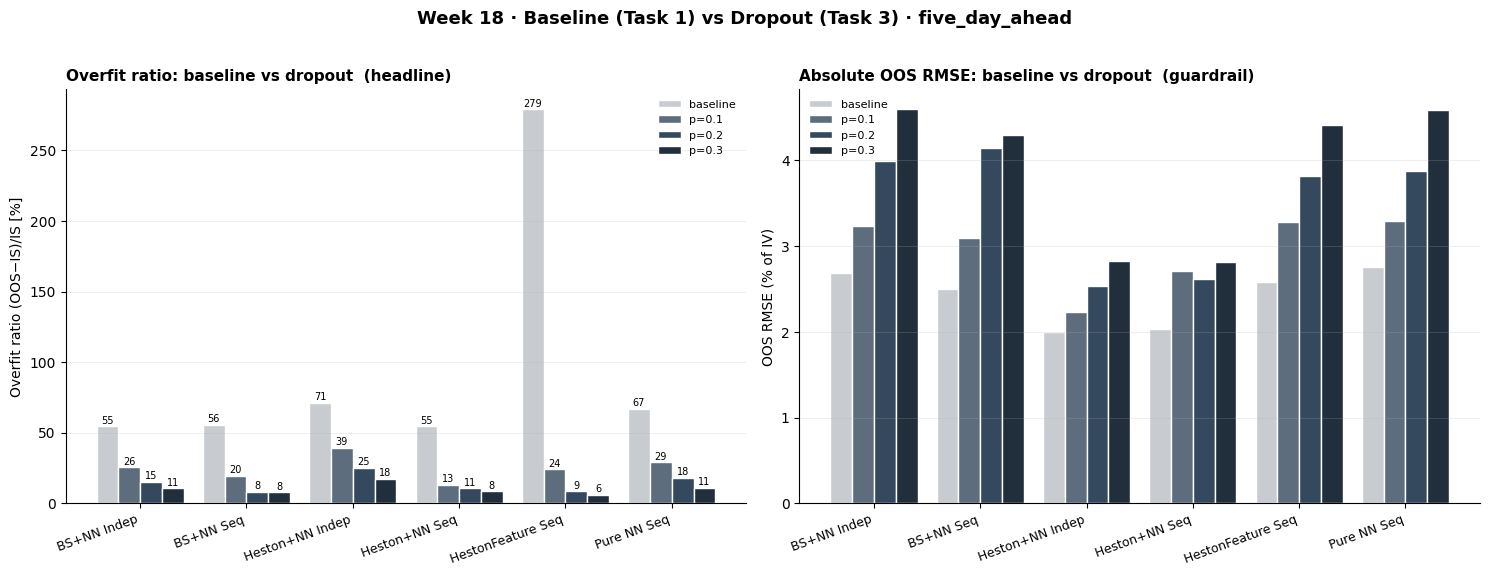

In [ ]:
# =============================================================================
# CELL 18.2 — Dropout sweep vs baseline: summary tables + bars.
#   Depends only on Cell 18.1. (Task-3 focus; three-task view is in 18.5.)
#
#   At the focal horizon, compares baseline (p=0) against each dropout level.
#   Tables show overfit ratio and absolute OOS; bars cluster by framework×mode
#   with one bar per dropout level, baseline leftmost.
# =============================================================================

sub = w18_df[(w18_df.horizon == FOCAL_H) &
             (w18_df.task.isin(["baseline", "dropout"]))].copy()
sub["plevel"] = sub["dropout_p"]

ratio_tbl = sub.pivot_table(index="label", columns="plevel", values="overfit_ratio_pct")
oos_tbl   = sub.pivot_table(index="label", columns="plevel", values="oos_rmse_pct")

def _fmt(tbl, nd):
    t = tbl.round(nd).copy()
    t.columns = [("baseline" if c == 0.0 else f"p={c}") for c in t.columns]
    return t

print("=" * 76)
print(f"WEEK 18 — Overfit ratio (%) = 100*(OOS-IS)/IS   ·   {FOCAL_H}")
print("=" * 76)
print(_fmt(ratio_tbl, 1).to_string())
print("\n" + "=" * 76)
print(f"WEEK 18 — Absolute OOS RMSE (%) [guardrail]   ·   {FOCAL_H}")
print("=" * 76)
print(_fmt(oos_tbl, 3).to_string())
print("\nbaseline = Task 1 (no dropout). Want: ratio falls below baseline as p "
      "rises,\nwithout OOS RMSE climbing above baseline.")

configs = ratio_tbl.index.tolist()
x = np.arange(len(configs))
levels = list(ratio_tbl.columns)
nL = len(levels)
width = 0.82 / nL
_pos_levels = [p for p in levels if p > 0]
_ramp = ["#5d6d7e", "#34495e", "#212f3d", "#0b141c"]
shade = {}
for lvl in levels:
    if lvl == 0.0:
        shade[lvl] = "#c8ccd0"
    else:
        i = _pos_levels.index(lvl)
        shade[lvl] = _ramp[i] if i < len(_ramp) else _ramp[-1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.6))
for j, lvl in enumerate(levels):
    offs = (j - (nL - 1) / 2) * width
    vr = [ratio_tbl.loc[c, lvl] if not pd.isna(ratio_tbl.loc[c, lvl]) else np.nan for c in configs]
    vo = [oos_tbl.loc[c, lvl]   if not pd.isna(oos_tbl.loc[c, lvl])   else np.nan for c in configs]
    lab = "baseline" if lvl == 0.0 else f"p={lvl}"
    axL.bar(x + offs, vr, width=width, color=shade[lvl], edgecolor="white", label=lab)
    axR.bar(x + offs, vo, width=width, color=shade[lvl], edgecolor="white", label=lab)
    for xi, v in zip(x + offs, vr):
        if not np.isnan(v):
            axL.text(xi, v + 0.5, f"{v:.0f}", ha="center", va="bottom", fontsize=7)

for ax, ttl, ylab in [
    (axL, "Overfit ratio: baseline vs dropout  (headline)", "Overfit ratio (OOS−IS)/IS [%]"),
    (axR, "Absolute OOS RMSE: baseline vs dropout  (guardrail)", "OOS RMSE (% of IV)")]:
    ax.set_xticks(x); ax.set_xticklabels(configs, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(ttl, fontsize=11, fontweight="bold", loc="left")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

fig.suptitle(f"Week 18 · Baseline (Task 1) vs Dropout (Task 3) · {FOCAL_H}",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
out_png = os.path.join(fig_dir_w18, f"w18_baseline_vs_dropout_summary_{FOCAL_H}.png")
os.makedirs(os.path.dirname(out_png), exist_ok=True)
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("\nSaved:", out_png)
plt.show()

Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures/w18_dropout_sweep_from_baseline_five_day_ahead.png


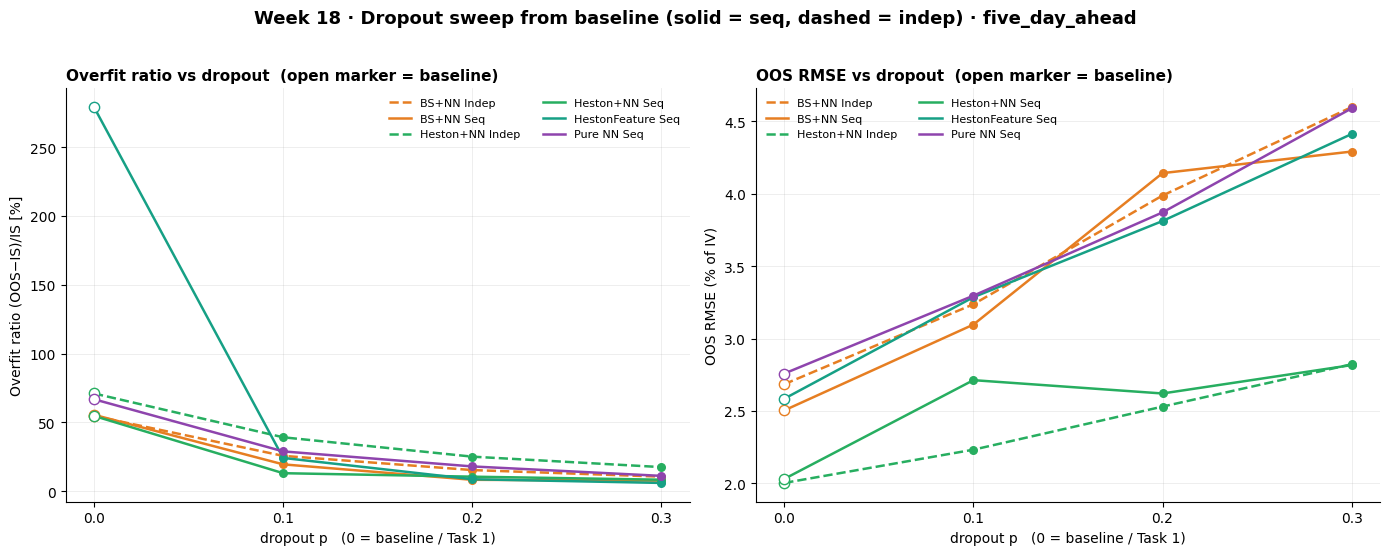

In [ ]:
# =============================================================================
# CELL 18.3 — Dropout trend with baseline as the p=0 anchor.
#   Depends only on Cell 18.1.
#
#   x = dropout p, baseline at p=0 (open marker). Left = overfit ratio
#   (want downward from baseline); right = OOS RMSE (want not rising).
# =============================================================================

sub = w18_df[(w18_df.horizon == FOCAL_H) &
             (w18_df.task.isin(["baseline", "dropout"]))].copy()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.4))
for label, g in sub.groupby("label"):
    g = g.sort_values("dropout_p")
    color = g["color"].iloc[0]
    ls = "--" if g["mode"].iloc[0] == "independent" else "-"
    axL.plot(g["dropout_p"], g["overfit_ratio_pct"], ls, color=color, lw=1.8, label=label)
    axR.plot(g["dropout_p"], g["oos_rmse_pct"],     ls, color=color, lw=1.8, label=label)
    b = g[g.dropout_p == 0.0]
    if len(b):
        axL.scatter(b["dropout_p"], b["overfit_ratio_pct"], facecolors="white",
                    edgecolors=color, s=55, zorder=5)
        axR.scatter(b["dropout_p"], b["oos_rmse_pct"], facecolors="white",
                    edgecolors=color, s=55, zorder=5)
    axL.scatter(g[g.dropout_p > 0]["dropout_p"], g[g.dropout_p > 0]["overfit_ratio_pct"],
                color=color, s=30, zorder=5)
    axR.scatter(g[g.dropout_p > 0]["dropout_p"], g[g.dropout_p > 0]["oos_rmse_pct"],
                color=color, s=30, zorder=5)

_xt = sorted(sub["dropout_p"].unique())
for ax, ttl, ylab in [
    (axL, "Overfit ratio vs dropout  (open marker = baseline)", "Overfit ratio (OOS−IS)/IS [%]"),
    (axR, "OOS RMSE vs dropout  (open marker = baseline)", "OOS RMSE (% of IV)")]:
    ax.set_xlabel("dropout p   (0 = baseline / Task 1)", fontsize=10)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_xticks(_xt)
    ax.set_title(ttl, fontsize=11, fontweight="bold", loc="left")
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8, frameon=False, ncol=2)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

fig.suptitle(f"Week 18 · Dropout sweep from baseline (solid = seq, dashed = indep) · {FOCAL_H}",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
out_png = os.path.join(fig_dir_w18, f"w18_dropout_sweep_from_baseline_{FOCAL_H}.png")
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("Saved:", out_png)
plt.show()

Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures/w18_ma60_is_vs_oos_baseline_and_dropout_five_day_ahead.png


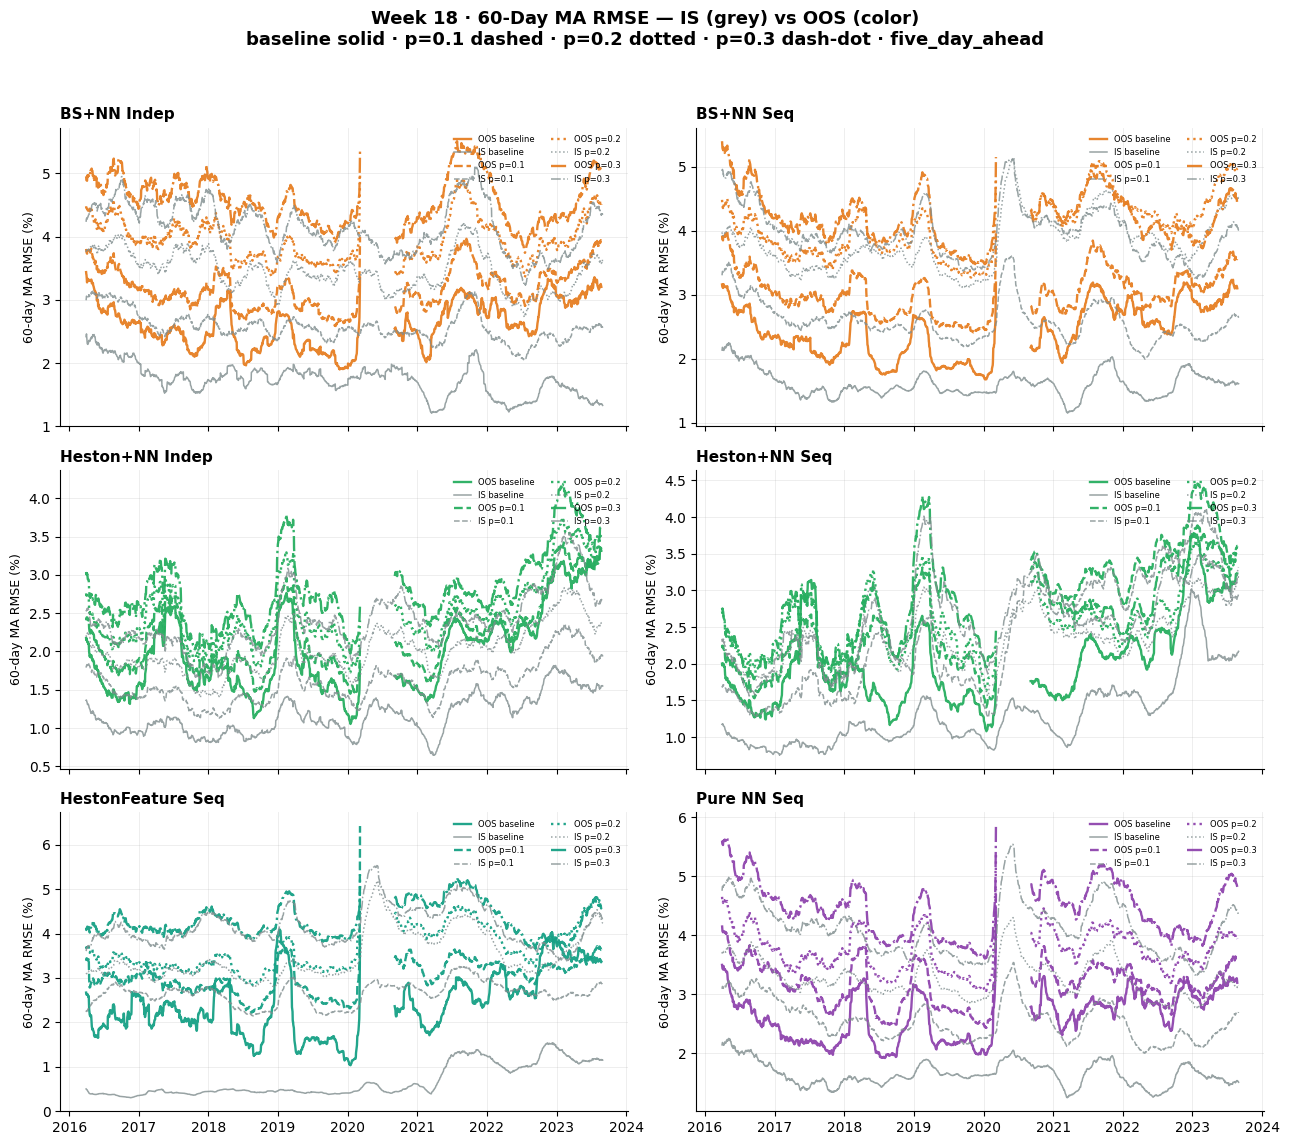

In [ ]:
# =============================================================================
# CELL 18.4 — 60-day MA IS vs OOS: baseline overlaid against dropout levels.
#   Depends only on Cell 18.1 (uses w18_ma). W18_DAILY keys are 5-tuples
#   (fw, mode, horizon, task, dropout_p): baseline = task='baseline' at p=0.0.
# =============================================================================

panels = (w18_df[(w18_df.horizon == FOCAL_H) &
                 (w18_df.task.isin(["baseline", "dropout"]))]
          [["framework", "mode", "label", "color"]]
          .drop_duplicates().sort_values(["framework", "mode"]).to_records(index=False))

ncol = 2
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.8 * nrow), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, (fw, mode, label, color) in zip(axes, panels):
    drew = False
    series_specs = [("baseline", 0.0)] + [("dropout", p) for p in W18_DROPOUTS]
    for task, p in series_specs:
        df = W18_DAILY.get((fw, mode, FOCAL_H, task, p))
        if df is None:
            continue
        ls = W18_DROP_STYLE.get(p, "-")
        tag = "baseline" if task == "baseline" else f"p={p}"
        ax.plot(df.index, w18_ma(df["oos"]), color=color, lw=1.7,
                linestyle=ls, alpha=0.95, label=f"OOS {tag}")
        ax.plot(df.index, w18_ma(df["is"]), color="#7f8c8d", lw=1.1,
                linestyle=ls, alpha=0.8, label=f"IS {tag}")
        drew = True
    if not drew:
        ax.set_visible(False); continue
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left", pad=6)
    ax.set_ylabel("60-day MA RMSE (%)", fontsize=9)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=6, frameon=False, ncol=2, loc="upper right")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

for ax in axes[len(panels):]:
    ax.set_visible(False)

fig.suptitle(
    f"Week 18 · 60-Day MA RMSE — IS (grey) vs OOS (color)\n"
    f"baseline solid · p=0.1 dashed · p=0.2 dotted · p=0.3 dash-dot · {FOCAL_H}",
    fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.975])
out_png = os.path.join(fig_dir_w18, f"w18_ma60_is_vs_oos_baseline_and_dropout_{FOCAL_H}.png")
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("Saved:", out_png)
plt.show()

/tmp/ipykernel_5944/2530403997.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best = (sub.groupby(["label", "task"], group_keys=False).apply(_pick)


Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures/w18_three_task_comparison_five_day_ahead.png


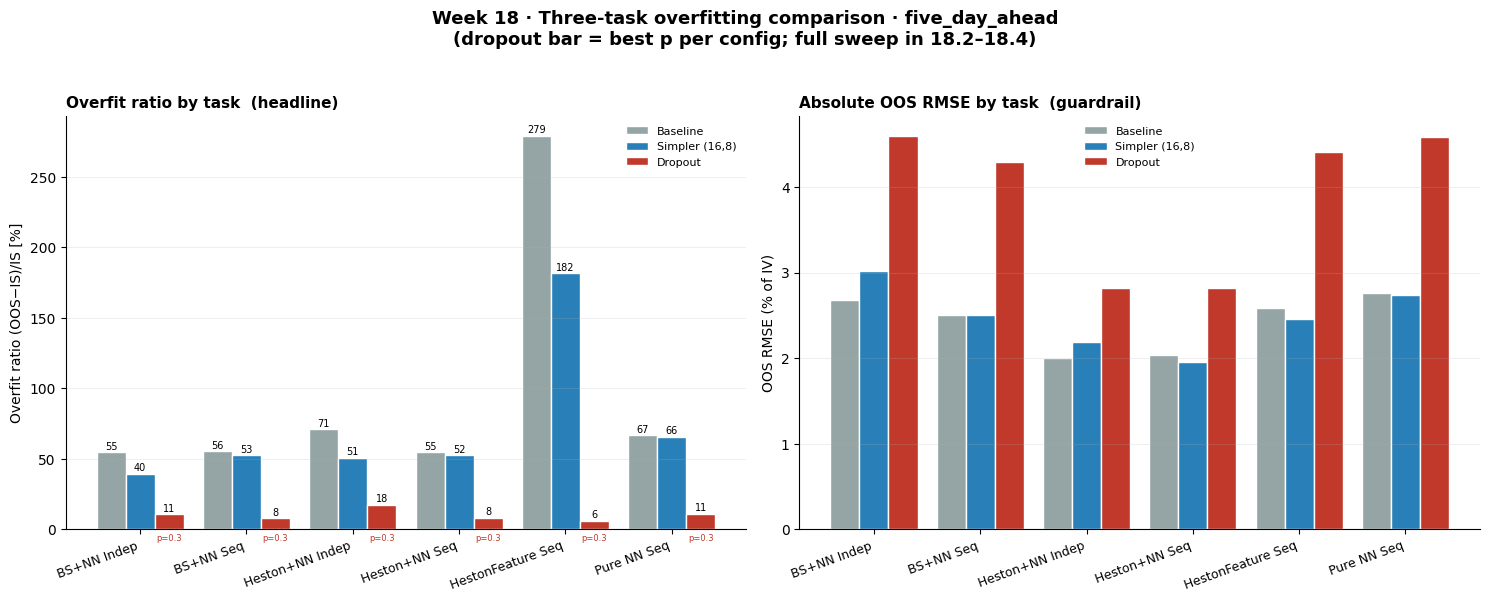

In [ ]:
# =============================================================================
# CELL 18.5 — Three-task overfitting comparison: Baseline vs Simpler vs Dropout.
#   Depends only on Cell 18.1.
#
#   Headline Week 18 deliverable: do either regularization route (simpler arch,
#   or dropout) reduce the baseline's overfitting gap, and at what OOS cost? For
#   dropout we use the best level per config (lowest overfit ratio); full sweep
#   is in 18.2-18.4.
#     Left  = overfit ratio by task   (headline; want below baseline)
#     Right = absolute OOS RMSE by task (guardrail; want not above baseline)
# =============================================================================

sub = w18_df[w18_df.horizon == FOCAL_H].copy()

def _pick(g):
    if g["task"].iloc[0] == "dropout":
        return g.loc[g["overfit_ratio_pct"].idxmin()]
    return g.iloc[0]
best = (sub.groupby(["label", "task"], group_keys=False).apply(_pick)
            .reset_index(drop=True))

configs = sorted(best["label"].unique())
tasks_present = [t for t in W18_TASKS if t in set(best["task"])]
x = np.arange(len(configs))
nT = len(tasks_present)
width = 0.82 / nT
best["bar_note"] = best.apply(
    lambda r: f"p={r.dropout_p:g}" if r.task == "dropout" else "", axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.8))
for j, task in enumerate(tasks_present):
    offs = (j - (nT - 1) / 2) * width
    gt = best[best.task == task].set_index("label")
    vr = [gt.loc[c, "overfit_ratio_pct"] if c in gt.index else np.nan for c in configs]
    vo = [gt.loc[c, "oos_rmse_pct"]      if c in gt.index else np.nan for c in configs]
    notes = [gt.loc[c, "bar_note"] if c in gt.index else "" for c in configs]
    axL.bar(x + offs, vr, width=width, color=W18_TASK_COLOR[task],
            edgecolor="white", label=W18_TASK_LABEL[task])
    axR.bar(x + offs, vo, width=width, color=W18_TASK_COLOR[task],
            edgecolor="white", label=W18_TASK_LABEL[task])
    for xi, v, nt in zip(x + offs, vr, notes):
        if not np.isnan(v):
            axL.text(xi, v + 0.6, f"{v:.0f}", ha="center", va="bottom", fontsize=7)
            if nt:
                axL.text(xi, -3.2, nt, ha="center", va="top", fontsize=6,
                         color=W18_TASK_COLOR[task])

for ax, ttl, ylab in [
    (axL, "Overfit ratio by task  (headline)", "Overfit ratio (OOS−IS)/IS [%]"),
    (axR, "Absolute OOS RMSE by task  (guardrail)", "OOS RMSE (% of IV)")]:
    ax.set_xticks(x); ax.set_xticklabels(configs, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(ttl, fontsize=11, fontweight="bold", loc="left")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

fig.suptitle(
    f"Week 18 · Three-task overfitting comparison · {FOCAL_H}\n"
    f"(dropout bar = best p per config; full sweep in 18.2–18.4)",
    fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
out_png = os.path.join(fig_dir_w18, f"w18_three_task_comparison_{FOCAL_H}.png")
os.makedirs(os.path.dirname(out_png), exist_ok=True)
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("Saved:", out_png)
plt.show()

In [ ]:
# =============================================================================
# CELL 18.6a — Load Table-6 (call/put × moneyness) JSONs across all tasks.
#   Depends on Cell 18.1 (reuses the roots, fname regex, task/framework maps).
#   Run once after 18.1. Populates:
#     W18_T6_SUMMARY  -> rows of sample-averaged OOS RMSE per C/P × bucket
#     W18_T6_DAILY    -> (fw, mode, horizon, task, dropout_p) -> daily DataFrame
#                        with columns C_ITM C_ATM C_OTM P_ITM P_ATM P_OTM
# =============================================================================

_T6_FNAME_RE = re.compile(
    r"^table6_(BS_NN|Heston_NN|Pure_NN|HestonFeature)_"
    r"(independent|sequential)_"
    r"(same_day|one_day_ahead|five_day_ahead)\.json$"
)
W18_CELLS6 = ["C_ITM", "C_ATM", "C_OTM", "P_ITM", "P_ATM", "P_OTM"]

# We need dropout_p per file. table6 files don't carry it, so borrow it from the
# matching results row already in w18_df (same fw/mode/horizon/task).
def _drop_for(fw, mode, horizon, task):
    q = w18_df[(w18_df.framework == fw) & (w18_df["mode"] == mode) &
               (w18_df.horizon == horizon) & (w18_df.task == task)]
    return float(q["dropout_p"].iloc[0]) if len(q) else 0.0

W18_T6_SUMMARY = []
W18_T6_DAILY = {}
_t6_skipped = []

def _ingest_t6(root, task):
    if not root or not os.path.isdir(root):
        return 0
    n = 0
    for path in sorted(glob.glob(os.path.join(root, "**", "table6_*.json"),
                                 recursive=True)):
        fname = os.path.basename(path)
        m = _T6_FNAME_RE.match(fname)
        if not m:
            _t6_skipped.append(fname); continue
        model_key, mode, horizon = m.group(1), m.group(2), m.group(3)
        with open(path) as f:
            d = json.load(f)
        fw = W18_FW_DISPLAY[model_key]
        drop = _drop_for(fw, mode, horizon, task)

        summ = d.get("table6_summary", {})
        row = {"framework": fw, "mode": mode, "horizon": horizon, "task": task,
               "dropout_p": drop,
               "label": f"{fw} {('Indep' if mode=='independent' else 'Seq')}"}
        for cp in ["C", "P"]:
            for b in ["ITM", "ATM", "OTM"]:
                row[f"{cp}_{b}"] = summ.get(cp, {}).get(b, np.nan)
        W18_T6_SUMMARY.append(row)

        drows = []
        for r in d.get("daily_callput_bucket_rmses", []):
            cb = r["callput_bucket_rmses"]
            dr = {"date": pd.Timestamp(r["date"])}
            for cp in ["C", "P"]:
                for b in ["ITM", "ATM", "OTM"]:
                    dr[f"{cp}_{b}"] = cb.get(cp, {}).get(b, np.nan)
            drows.append(dr)
        if drows:
            W18_T6_DAILY[(fw, mode, horizon, task, drop)] = (
                pd.DataFrame(drows).sort_values("date").set_index("date"))
        n += 1
    return n

_n6 = (_ingest_t6(W18_BASELINE_ROOT, "baseline") +
       _ingest_t6(W18_SIMPLER_ROOT,  "simpler") +
       _ingest_t6(W18_DROPOUT_ROOT,  "dropout"))
w18_t6 = pd.DataFrame(W18_T6_SUMMARY)
print(f"Loaded {_n6} table6 files -> {len(w18_t6)} summary rows, "
      f"{len(W18_T6_DAILY)} daily series.")
if _t6_skipped:
    print(f"[ignored {len(_t6_skipped)} non-matching] e.g. {_t6_skipped[:3]}")
if len(w18_t6):
    print("\nSample-averaged OOS RMSE (%) by C/P × bucket — dropout task only:")
    _dd = w18_t6[w18_t6.task == "dropout"].sort_values(["label", "dropout_p"])
    print(_dd[["label", "dropout_p"] + W18_CELLS6].round(3).to_string(index=False))

Loaded 18 table6 files -> 18 summary rows, 6 daily series.

Sample-averaged OOS RMSE (%) by C/P × bucket — dropout task only:
            label  dropout_p  C_ITM  C_ATM  C_OTM  P_ITM  P_ATM  P_OTM
      BS+NN Indep        0.1  4.299  2.031  2.470  2.826  1.875  2.190
      BS+NN Indep        0.1  5.301  2.501  3.235  3.649  2.326  2.491
      BS+NN Indep        0.1  6.057  2.977  3.995  4.283  2.796  2.762
        BS+NN Seq        0.1  4.402  1.979  2.358  2.252  1.826  1.918
        BS+NN Seq        0.1  5.696  2.319  3.221  3.843  2.151  2.342
        BS+NN Seq        0.1  6.350  2.372  3.142  3.021  2.194  2.468
  Heston+NN Indep        0.1  2.758  0.891  1.336  2.587  0.982  1.391
  Heston+NN Indep        0.1  3.130  1.050  1.310  3.099  1.185  1.478
  Heston+NN Indep        0.1  3.477  1.181  1.327  3.570  1.348  1.572
    Heston+NN Seq        0.1  3.184  1.094  1.361  3.562  1.244  1.510
    Heston+NN Seq        0.1  3.365  1.069  1.260  3.041  1.208  1.480
    Heston+NN Seq     

In [ ]:
# =============================================================================
# CELL 18.6b — Synthesize baseline & simpler 6-cell table from results_ files.
#   Depends on Cell 18.1 (roots, maps) and Cell 18.6a (w18_t6, W18_T6_DAILY,
#   W18_CELLS6). Run once, after 18.6a, before 18.7.
#
#   The baseline/simpler runs never wrote table6_*.json, but their results_*.json
#   carry the same 6-cell info per day in `callput_bucket_rmses`. This cell
#   sample-averages that field to produce the missing baseline/simpler rows so
#   18.7 has a true reference bar — no pipeline re-run required.
# =============================================================================

def _ingest_results_callput(root, task):
    """Build 6-cell summary + daily from results_*.json `callput_bucket_rmses`."""
    added = 0
    if not root or not os.path.isdir(root):
        return 0
    for path in sorted(glob.glob(os.path.join(root, "**", "results_*.json"),
                                 recursive=True)):
        fname = os.path.basename(path)
        m = _W18_FNAME_RE.match(fname)          # reuse 18.1's results regex
        if not m:
            continue
        model_key, mode, horizon = m.group(1), m.group(2), m.group(3)
        with open(path) as f:
            d = json.load(f)
        fw = W18_FW_DISPLAY[model_key]
        drop = float(d.get("regularization", {}).get("dropout_p", 0.0))

        # daily 6-cell frame
        drows = []
        for r in d["daily"]:
            cb = r.get("callput_bucket_rmses")
            if not cb:
                continue
            dr = {"date": pd.Timestamp(r["date"])}
            for cp in ["C", "P"]:
                for b in ["ITM", "ATM", "OTM"]:
                    dr[f"{cp}_{b}"] = cb.get(cp, {}).get(b, np.nan)
            drows.append(dr)
        if not drows:
            continue
        ddf = pd.DataFrame(drows).sort_values("date").set_index("date")
        W18_T6_DAILY[(fw, mode, horizon, task, drop)] = ddf

        # sample-averaged summary row (mean over days, matching table6_summary)
        row = {"framework": fw, "mode": mode, "horizon": horizon, "task": task,
               "dropout_p": drop,
               "label": f"{fw} {('Indep' if mode=='independent' else 'Seq')}",
               "src_folder": os.path.basename(os.path.dirname(path))}
        for c in W18_CELLS6:
            row[c] = ddf[c].mean()
        W18_T6_SUMMARY.append(row)
        added += 1
    return added

# Only synthesize tasks that are MISSING from table6 (don't double-count dropout)
_have_tasks = set(w18_t6["task"].unique()) if len(w18_t6) else set()
_added = 0
if "baseline" not in _have_tasks:
    _added += _ingest_results_callput(W18_BASELINE_ROOT, "baseline")
if "simpler" not in _have_tasks:
    _added += _ingest_results_callput(W18_SIMPLER_ROOT, "simpler")

# rebuild the summary frame
w18_t6 = pd.DataFrame(W18_T6_SUMMARY)
print(f"Synthesized {_added} baseline/simpler 6-cell rows from results_ files.")
print("\nTable6 rows now by task & dropout level:")
print(w18_t6.groupby(["task", "dropout_p"]).size().to_string())
print("\nFocal-horizon coverage (should include baseline now):")
print(w18_t6[w18_t6.horizon == FOCAL_H].groupby(["task", "dropout_p"]).size().to_string())

Synthesized 36 baseline/simpler 6-cell rows from results_ files.

Table6 rows now by task & dropout level:
task      dropout_p
baseline  0.0          18
dropout   0.1           6
          0.2           6
          0.3           6
simpler   0.0          18

Focal-horizon coverage (should include baseline now):
task      dropout_p
baseline  0.0          6
dropout   0.1          6
          0.2          6
          0.3          6
simpler   0.0          6


Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures/w18_ma60_oos_by_moneyness_five_day_ahead.png


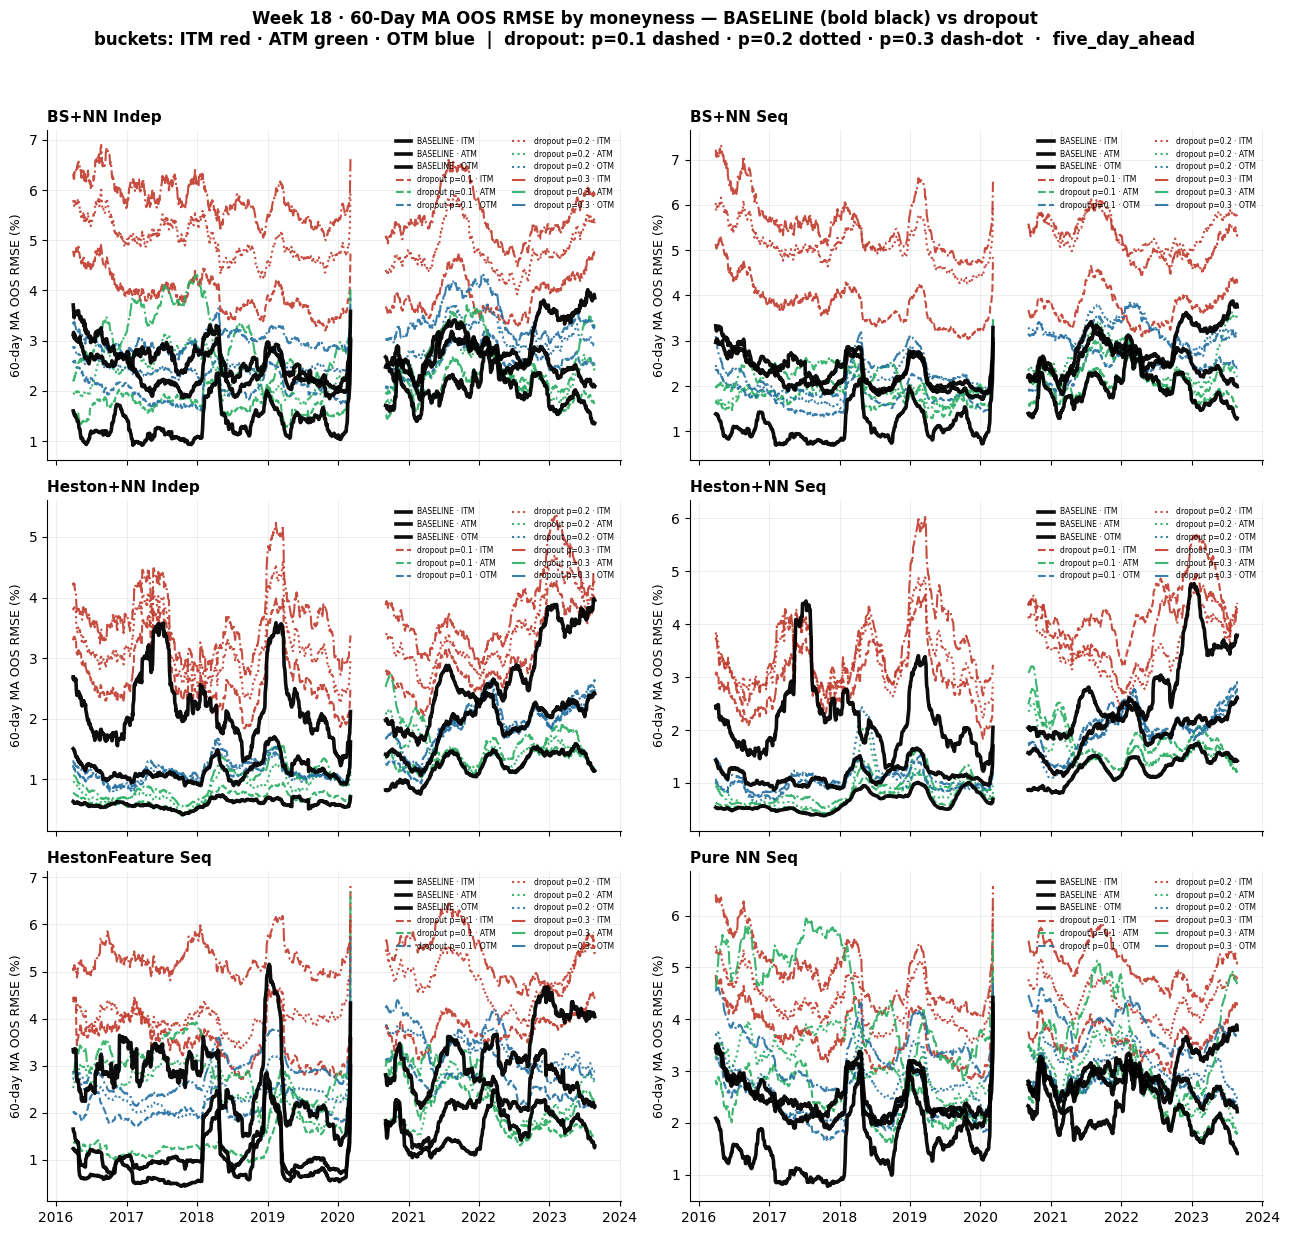

In [ ]:
# =============================================================================
# CELL 18.6 — 3-bucket OOS RMSE over time (ITM/ATM/OTM), dropout vs baseline.
#   Depends only on Cell 18.1 (uses w18_ma and b_ITM/b_ATM/b_OTM in W18_DAILY).
#   Pooled across call/put.
#
#   One panel per framework×mode at the focal horizon. BASELINE is drawn BOLD
#   BLACK (solid, thick) as the unmistakable reference; the three dropout levels
#   use the bucket color with distinct line styles. Reads: does any dropout
#   level pull a bucket below its bold-black baseline line?
# =============================================================================

W18_BUCKET_COLOR = {"ITM": "#c0392b", "ATM": "#27ae60", "OTM": "#2471a3"}
# dropout line styles (baseline handled separately in bold black)
_DROP_LS = {0.1: "--", 0.2: ":", 0.3: "-."}

panels = (w18_df[(w18_df.horizon == FOCAL_H) &
                 (w18_df.task.isin(["baseline", "dropout"]))]
          [["framework", "mode", "label"]]
          .drop_duplicates().sort_values(["framework", "mode"]).to_records(index=False))

ncol = 2
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.1 * nrow), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, (fw, mode, label) in zip(axes, panels):
    drew = False

    # ── BASELINE first: bold black, one line per bucket, clearly labeled ──────
    base_df = W18_DAILY.get((fw, mode, FOCAL_H, "baseline", 0.0))
    if base_df is not None:
        for b in ["ITM", "ATM", "OTM"]:
            col = f"b_{b}"
            if col in base_df and not base_df[col].isna().all():
                ax.plot(base_df.index, w18_ma(base_df[col]),
                        color="black", lw=2.6, linestyle="-", alpha=0.95,
                        label=f"BASELINE · {b}", zorder=6)
        drew = True

    # ── DROPOUT levels: bucket color, distinct styles, clearly labeled ────────
    for p in W18_DROPOUTS:
        df = W18_DAILY.get((fw, mode, FOCAL_H, "dropout", p))
        if df is None:
            continue
        ls = _DROP_LS.get(p, "--")
        for b in ["ITM", "ATM", "OTM"]:
            col = f"b_{b}"
            if col in df and not df[col].isna().all():
                ax.plot(df.index, w18_ma(df[col]), color=W18_BUCKET_COLOR[b],
                        lw=1.5, linestyle=ls, alpha=0.9,
                        label=f"dropout p={p} · {b}")
        drew = True

    if not drew:
        ax.set_visible(False); continue
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left", pad=6)
    ax.set_ylabel("60-day MA OOS RMSE (%)", fontsize=9)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=5.5, frameon=False, ncol=2, loc="upper right")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

for ax in axes[len(panels):]:
    ax.set_visible(False)

fig.suptitle(
    f"Week 18 · 60-Day MA OOS RMSE by moneyness — BASELINE (bold black) vs dropout\n"
    f"buckets: ITM red · ATM green · OTM blue  |  dropout: p=0.1 dashed · p=0.2 dotted · p=0.3 dash-dot  ·  {FOCAL_H}",
    fontsize=12, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.975])
out_png = os.path.join(fig_dir_w18, f"w18_ma60_oos_by_moneyness_{FOCAL_H}.png")
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("Saved:", out_png)
plt.show()

Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week18_overfitting_study_dropout_vs_simpler/20260624-033805/figures/w18_table6_callput_moneyness_all_dropout_five_day_ahead.png


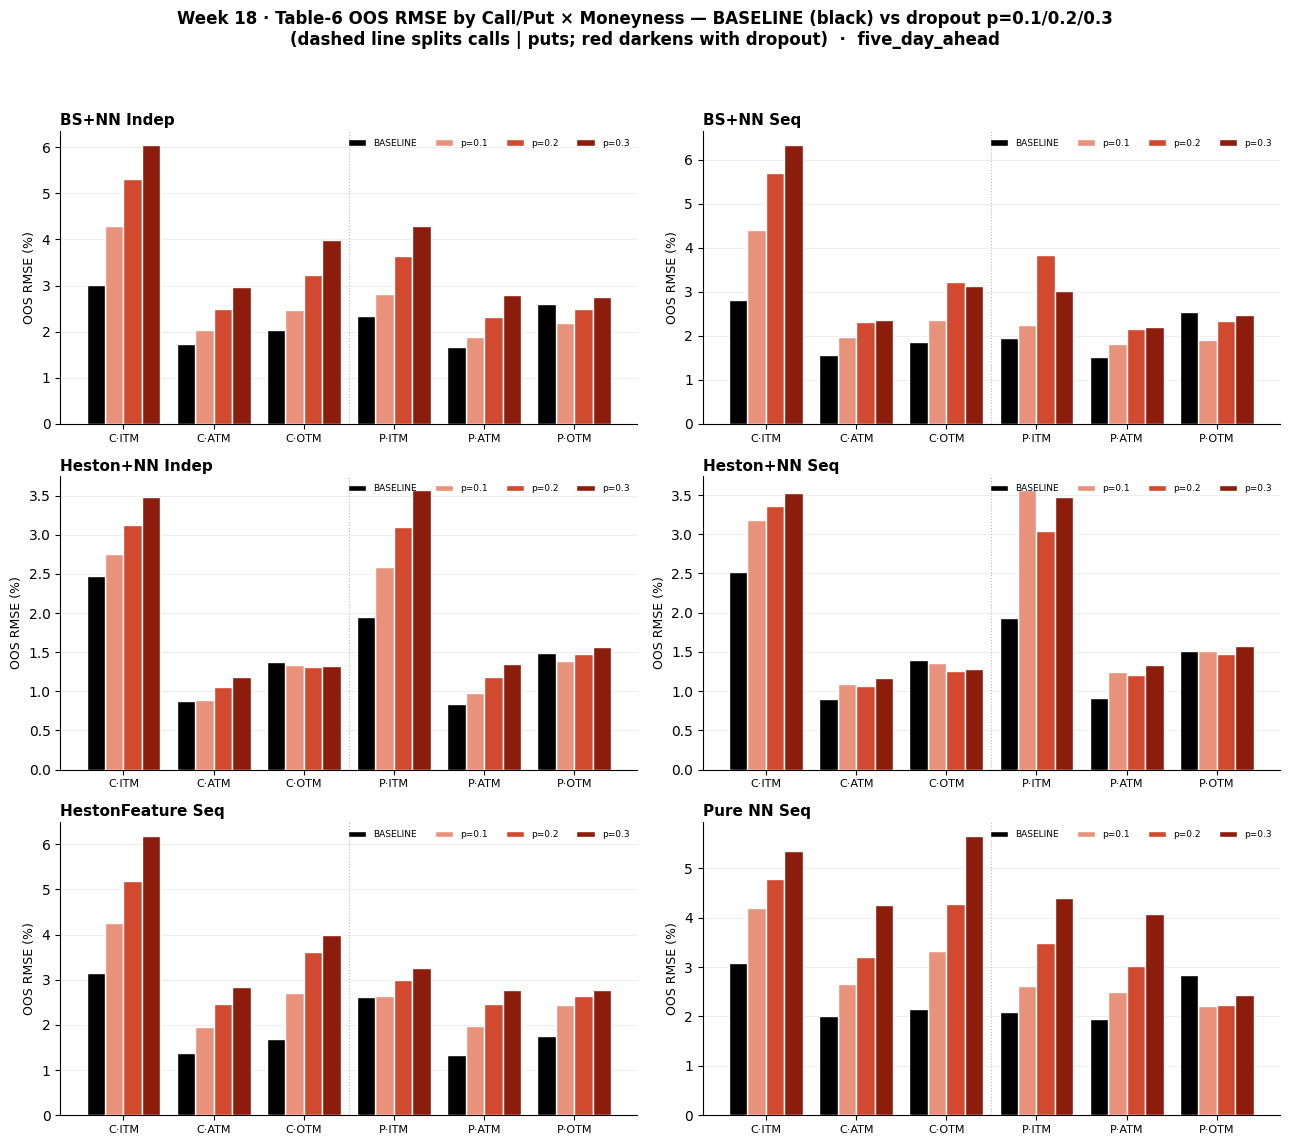

In [ ]:
# =============================================================================
# CELL 18.7 — Table-6 call/put × moneyness: baseline vs ALL dropout levels.
#   Depends on Cell 18.6a + 18.6b (w18_t6 with baseline rows synthesized).
#
#   The 6-cell Jiang Table-6 layout (C/P × ITM/ATM/OTM), sample-averaged OOS
#   RMSE. Per framework×mode at the focal horizon: 4 bars per cell — BASELINE
#   (bold black) then dropout p=0.1 / 0.2 / 0.3 in a darkening red ramp. Lets you
#   see whether higher dropout monotonically helps each cell (esp. deep-ITM
#   calls, the high-error corner) or overshoots.
# =============================================================================

if not len(w18_t6):
    print("No table6 data loaded — run Cells 18.6a and 18.6b first.")
else:
    sub6 = w18_t6[w18_t6.horizon == FOCAL_H].copy()
    labels6 = sorted(sub6["label"].unique())

    # bar series: baseline + each dropout level present
    drop_levels = sorted(sub6.loc[sub6.task == "dropout", "dropout_p"].unique())
    series = [("baseline", 0.0, "black", "BASELINE")]
    _red_ramp = {0.1: "#e8927c", 0.2: "#d1492f", 0.3: "#8c1c0c"}
    for p in drop_levels:
        series.append(("dropout", p, _red_ramp.get(p, "#c0392b"), f"p={p}"))

    nbars = len(series)
    npan = len(labels6)
    ncol = 2
    nrow = int(np.ceil(npan / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.8 * nrow))
    axes = np.array(axes).reshape(-1)
    cell_x = np.arange(len(W18_CELLS6))
    w = 0.82 / nbars

    for ax, label in zip(axes, labels6):
        g = sub6[sub6.label == label]
        any_drawn = False
        for k, (task, p, color, lab) in enumerate(series):
            row = g[(g.task == task) & (g.dropout_p == p)]
            if not len(row):
                continue
            row = row.iloc[0]
            offs = (k - (nbars - 1) / 2) * w
            vals = [row[c] for c in W18_CELLS6]
            ax.bar(cell_x + offs, vals, width=w, color=color,
                   edgecolor="white",
                   label=lab,
                   zorder=(6 if task == "baseline" else 3))
            any_drawn = True
        if not any_drawn:
            ax.set_visible(False); continue
        ax.set_title(label, fontsize=11, fontweight="bold", loc="left", pad=4)
        ax.set_xticks(cell_x)
        ax.set_xticklabels(["C·ITM", "C·ATM", "C·OTM", "P·ITM", "P·ATM", "P·OTM"],
                           fontsize=8)
        ax.set_ylabel("OOS RMSE (%)", fontsize=9)
        ax.axvline(2.5, color="#bbb", lw=0.8, linestyle=":")  # split calls|puts
        ax.grid(axis="y", alpha=0.25, linewidth=0.6)
        ax.legend(fontsize=6.5, frameon=False, ncol=nbars, loc="upper right")
        for s in ["top", "right"]: ax.spines[s].set_visible(False)

    for ax in axes[npan:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Week 18 · Table-6 OOS RMSE by Call/Put × Moneyness — BASELINE (black) vs dropout p=0.1/0.2/0.3\n"
        f"(dashed line splits calls | puts; red darkens with dropout)  ·  {FOCAL_H}",
        fontsize=12, fontweight="bold", y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out_png = os.path.join(fig_dir_w18, f"w18_table6_callput_moneyness_all_dropout_{FOCAL_H}.png")
    fig.savefig(out_png, dpi=140, bbox_inches="tight")
    print("Saved:", out_png)
    plt.show()

In [ ]:
# =============================================================================
# CELL 18.8 — Horizon-pair % difference of mean OOS RMSE, by Call/Put × Moneyness.
#   Baseline (paper arch) vs Simpler (16,8) arch. Dropout excluded (5-day only).
# =============================================================================

import os, glob, json
import numpy as np
import pandas as pd
from IPython.display import display, HTML

_W18_RUN    = "runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614"
_W18_BASE   = os.path.join(_W18_RUN, "800_32")
_W18_SIMP   = os.path.join(_W18_RUN, "800_32_simpler")
_W18_FIGDIR = os.path.join(_W18_RUN, "figures")
print("baseline root:", _W18_BASE)
print("simpler  root:", _W18_SIMP)

_FAMILIES = [
    ("BS_NN",         "independent", "BS+NN Indep"),
    ("BS_NN",         "sequential",  "BS+NN Seq"),
    ("Heston_NN",     "independent", "Heston+NN Indep"),
    ("Heston_NN",     "sequential",  "Heston+NN Seq"),
    ("HestonFeature", "sequential",  "HestonFeature Seq"),
    ("Pure_NN",       "sequential",  "Pure NN Seq"),
]

_HORIZONS = {
    "same": "same_day",
    "one":  "one_day_ahead",
    "five": "five_day_ahead",
}

_PAIRS = [("same", "one"), ("same", "five"), ("one", "five")]

_PAIR_LABEL = {
    ("same", "one"):  "same → 1-day",
    ("same", "five"): "same → 5-day",
    ("one", "five"):  "1-day → 5-day",
}

_CELLS = [
    ("C", "ITM"), ("C", "ATM"), ("C", "OTM"),
    ("P", "ITM"), ("P", "ATM"), ("P", "OTM"),
]

_CELL_LABEL = {
    ("C", "ITM"): "Call ITM",
    ("C", "ATM"): "Call ATM",
    ("C", "OTM"): "Call OTM",
    ("P", "ITM"): "Put ITM",
    ("P", "ATM"): "Put ATM",
    ("P", "OTM"): "Put OTM",
}


def _w188_mean_cells(root, model, mode, horizon_key):
    """Return {(cp,bucket): mean-over-days OOS RMSE} for one results file, or None."""
    fname = f"results_{model}_{mode}_{_HORIZONS[horizon_key]}.json"
    path = os.path.join(root, fname)

    if not os.path.exists(path):
        return None

    with open(path) as f:
        d = json.load(f)

    acc = {c: [] for c in _CELLS}

    for r in d["daily"]:
        cpb = r.get("callput_bucket_rmses", {})
        for cp, b in _CELLS:
            v = cpb.get(cp, {}).get(b)
            if v is not None:
                acc[(cp, b)].append(v)

    return {c: (float(np.mean(v)) if v else np.nan) for c, v in acc.items()}


def _pct_diff(long_v, short_v):
    """Paper-style: (long - short)/short * 100. NaN-safe."""
    if np.isnan(long_v) or np.isnan(short_v) or short_v == 0:
        return np.nan
    return (long_v - short_v) / short_v * 100.0


def _task_means(root):
    """{(model,mode): {horizon_key: {cell: mean}}}"""
    out = {}
    for model, mode, _ in _FAMILIES:
        out[(model, mode)] = {
            hk: _w188_mean_cells(root, model, mode, hk) for hk in _HORIZONS
        }
    return out


_base_means = _task_means(_W18_BASE)
_simp_means = _task_means(_W18_SIMP)

rows_188 = []

for model, mode, fam_label in _FAMILIES:
    for cp, b in _CELLS:
        row = {"Framework": fam_label, "Cell": _CELL_LABEL[(cp, b)]}

        for short_k, long_k in _PAIRS:
            pl = _PAIR_LABEL[(short_k, long_k)]

            bm = _base_means[(model, mode)]
            sm = _simp_means[(model, mode)]

            b_long  = (bm[long_k]  or {}).get((cp, b), np.nan) if bm[long_k]  else np.nan
            b_short = (bm[short_k] or {}).get((cp, b), np.nan) if bm[short_k] else np.nan

            s_long  = (sm[long_k]  or {}).get((cp, b), np.nan) if sm[long_k]  else np.nan
            s_short = (sm[short_k] or {}).get((cp, b), np.nan) if sm[short_k] else np.nan

            row[f"{pl}|base"] = _pct_diff(b_long, b_short)
            row[f"{pl}|simp"] = _pct_diff(s_long, s_short)

        rows_188.append(row)

df_188 = pd.DataFrame(rows_188)


def _w188_html(df):
    def cellpair(base_v, simp_v):
        def fmt(x):
            return "—" if (x is None or np.isnan(x)) else f"{x:+.2f}%"

        b_str, s_str = fmt(base_v), fmt(simp_v)

        b_ok = not (base_v is None or np.isnan(base_v))
        s_ok = not (simp_v is None or np.isnan(simp_v))

        # Lower % degradation is better.
        # Baseline winner = red. Simpler winner = green.
        base_win = b_ok and (not s_ok or base_v <= simp_v)
        simp_win = s_ok and (not b_ok or simp_v < base_v)

        def chip(txt, win, winner_type):
            if win and winner_type == "base":
                return (
                    f"<span style='color:#8A1F11;background:#FDE2E1;"
                    f"padding:1px 6px;border-radius:6px;font-weight:600'>{txt}</span>"
                )
            if win and winner_type == "simp":
                return (
                    f"<span style='color:#0F6E56;background:#E1F5EE;"
                    f"padding:1px 6px;border-radius:6px;font-weight:600'>{txt}</span>"
                )
            return f"<span style='color:#444'>{txt}</span>"

        return (
            f"<div style='line-height:1.5'>"
            f"<div style='font-size:11px;color:#888'>base</div>{chip(b_str, base_win, 'base')}"
            f"<div style='font-size:11px;color:#888;margin-top:3px'>simp</div>{chip(s_str, simp_win, 'simp')}"
            f"</div>"
        )

    pair_cols = [_PAIR_LABEL[p] for p in _PAIRS]

    header = """
    <div style='font-family:-apple-system,Segoe UI,sans-serif;margin-bottom:24px'>
      <div style='font-size:15px;font-weight:600;margin-bottom:6px'>
        Cell 18.8 &mdash; Horizon % difference of mean OOS RMSE, by Call/Put &times; Moneyness
      </div>
      <div style='font-size:12px;color:#666;margin-bottom:10px'>
        Paper-style % diff = (longer &minus; shorter) / shorter &times; 100, per framework &times; bucket-cell.
        Each cell shows <b>base</b> (paper arch, 800/32) over <b>simp</b> (16,8 arch).
        <span style='color:#8A1F11;background:#FDE2E1;padding:1px 6px;border-radius:6px'>red = baseline lower</span>,
        <span style='color:#0F6E56;background:#E1F5EE;padding:1px 6px;border-radius:6px'>green = simpler lower</span>.
        Lower is better. Dropout excluded (5-day only).
      </div>
      <table style='border-collapse:collapse;font-size:13px'>
        <thead><tr style='background:#2f4053;color:white'>
          <th style='padding:8px 12px;text-align:left;border:1px solid #222'>Framework</th>
          <th style='padding:8px 12px;text-align:left;border:1px solid #222'>Cell</th>
    """

    for pc in pair_cols:
        header += f"<th style='padding:8px 12px;border:1px solid #222'>{pc}</th>"

    header += "</tr></thead><tbody>"

    body = ""
    prev_fam = None

    for _, r in df.iterrows():
        fam = r["Framework"]
        top = "border-top:2px solid #999;" if fam != prev_fam else ""
        prev_fam = fam

        fam_cell = (
            f"<td style='padding:6px 12px;font-weight:500;vertical-align:top;{top}"
            f"border:1px solid #ccc'>{fam if top else ''}</td>"
        )

        body += (
            f"<tr>{fam_cell}"
            f"<td style='padding:6px 12px;{top}border:1px solid #ccc'>{r['Cell']}</td>"
        )

        for short_k, long_k in _PAIRS:
            pl = _PAIR_LABEL[(short_k, long_k)]
            body += (
                f"<td style='padding:6px 12px;text-align:center;{top}border:1px solid #ccc'>"
                f"{cellpair(r[f'{pl}|base'], r[f'{pl}|simp'])}</td>"
            )

        body += "</tr>"

    return header + body + "</tbody></table></div>"


display(HTML(_w188_html(df_188)))

_csv_188 = os.path.join(_W18_FIGDIR, "cell188_horizon_pctdiff_callput.csv")
os.makedirs(_W18_FIGDIR, exist_ok=True)
df_188.to_csv(_csv_188, index=False)

print("Saved:", _csv_188)

baseline root: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/800_32
simpler  root: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/800_32_simpler


Framework,Cell,same → 1-day,same → 5-day,1-day → 5-day
BS+NN Indep,Call ITM,base+33.55%simp+24.17%,base+49.53%simp+37.54%,base+11.96%simp+10.77%
,Call ATM,base+45.66%simp+20.99%,base+103.03%simp+52.58%,base+39.39%simp+26.11%
,Call OTM,base+6.86%simp+4.50%,base+18.47%simp+12.83%,base+10.87%simp+7.98%
,Put ITM,base+14.56%simp+4.63%,base+29.16%simp+12.99%,base+12.75%simp+8.00%
,Put ATM,base+51.65%simp+23.43%,base+116.20%simp+58.18%,base+42.57%simp+28.15%
,Put OTM,base+12.10%simp+9.87%,base+27.85%simp+22.04%,base+14.05%simp+11.08%
BS+NN Seq,Call ITM,base+25.37%simp+24.68%,base+40.59%simp+39.72%,base+12.14%simp+12.06%
,Call ATM,base+59.30%simp+61.89%,base+134.65%simp+136.48%,base+47.30%simp+46.08%
,Call OTM,base+7.69%simp+11.58%,base+20.79%simp+24.07%,base+12.17%simp+11.20%
,Put ITM,base+23.86%simp+26.75%,base+39.67%simp+43.57%,base+12.77%simp+13.27%


Saved: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/figures/cell188_horizon_pctdiff_callput.csv


In [ ]:
# =============================================================================
# CELL 18.9 — Horizon-pair % difference of mean OOS RMSE, by Moneyness only.
#   Uses bucket_rmses (ITM/ATM/OTM, call & put pooled). Baseline vs Simpler.
#   Depends on Cell 18.8.
# =============================================================================

_BUCKETS_189 = ["ITM", "ATM", "OTM"]


def _w189_mean_buckets(root, model, mode, horizon_key):
    """Return {bucket: mean-over-days OOS RMSE} for one results file, or None."""
    fname = f"results_{model}_{mode}_{_HORIZONS[horizon_key]}.json"
    path = os.path.join(root, fname)

    if not os.path.exists(path):
        return None

    with open(path) as f:
        d = json.load(f)

    acc = {b: [] for b in _BUCKETS_189}

    for r in d["daily"]:
        br = r.get("bucket_rmses", {})
        for b in _BUCKETS_189:
            v = br.get(b)
            if v is not None:
                acc[b].append(v)

    return {b: (float(np.mean(v)) if v else np.nan) for b, v in acc.items()}


def _task_means_189(root):
    out = {}
    for model, mode, _ in _FAMILIES:
        out[(model, mode)] = {
            hk: _w189_mean_buckets(root, model, mode, hk) for hk in _HORIZONS
        }
    return out


_base_means_189 = _task_means_189(_W18_BASE)
_simp_means_189 = _task_means_189(_W18_SIMP)

rows_189 = []

for model, mode, fam_label in _FAMILIES:
    for b in _BUCKETS_189:
        row = {"Framework": fam_label, "Bucket": b}

        for short_k, long_k in _PAIRS:
            pl = _PAIR_LABEL[(short_k, long_k)]

            bm = _base_means_189[(model, mode)]
            sm = _simp_means_189[(model, mode)]

            b_long  = (bm[long_k]  or {}).get(b, np.nan) if bm[long_k]  else np.nan
            b_short = (bm[short_k] or {}).get(b, np.nan) if bm[short_k] else np.nan

            s_long  = (sm[long_k]  or {}).get(b, np.nan) if sm[long_k]  else np.nan
            s_short = (sm[short_k] or {}).get(b, np.nan) if sm[short_k] else np.nan

            row[f"{pl}|base"] = _pct_diff(b_long, b_short)
            row[f"{pl}|simp"] = _pct_diff(s_long, s_short)

        rows_189.append(row)

df_189 = pd.DataFrame(rows_189)


def _w189_html(df):
    def cellpair(base_v, simp_v):
        def fmt(x):
            return "—" if (x is None or np.isnan(x)) else f"{x:+.2f}%"

        b_str, s_str = fmt(base_v), fmt(simp_v)

        b_ok = not (base_v is None or np.isnan(base_v))
        s_ok = not (simp_v is None or np.isnan(simp_v))

        # Lower % degradation is better.
        # Baseline winner = red. Simpler winner = green.
        base_win = b_ok and (not s_ok or base_v <= simp_v)
        simp_win = s_ok and (not b_ok or simp_v < base_v)

        def chip(txt, win, winner_type):
            if win and winner_type == "base":
                return (
                    f"<span style='color:#8A1F11;background:#FDE2E1;"
                    f"padding:1px 6px;border-radius:6px;font-weight:600'>{txt}</span>"
                )
            if win and winner_type == "simp":
                return (
                    f"<span style='color:#0F6E56;background:#E1F5EE;"
                    f"padding:1px 6px;border-radius:6px;font-weight:600'>{txt}</span>"
                )
            return f"<span style='color:#444'>{txt}</span>"

        return (
            f"<div style='line-height:1.5'>"
            f"<div style='font-size:11px;color:#888'>base</div>{chip(b_str, base_win, 'base')}"
            f"<div style='font-size:11px;color:#888;margin-top:3px'>simp</div>{chip(s_str, simp_win, 'simp')}"
            f"</div>"
        )

    pair_cols = [_PAIR_LABEL[p] for p in _PAIRS]

    header = """
    <div style='font-family:-apple-system,Segoe UI,sans-serif;margin-bottom:24px'>
      <div style='font-size:15px;font-weight:600;margin-bottom:6px'>
        Cell 18.9 &mdash; Horizon % difference of mean OOS RMSE, by Moneyness (Call &amp; Put pooled)
      </div>
      <div style='font-size:12px;color:#666;margin-bottom:10px'>
        Paper-style % diff = (longer &minus; shorter) / shorter &times; 100, per framework &times; bucket.
        Each cell shows <b>base</b> (paper arch, 800/32) over <b>simp</b> (16,8 arch).
        <span style='color:#8A1F11;background:#FDE2E1;padding:1px 6px;border-radius:6px'>red = baseline lower</span>,
        <span style='color:#0F6E56;background:#E1F5EE;padding:1px 6px;border-radius:6px'>green = simpler lower</span>.
        Lower is better. Dropout excluded (5-day only).
      </div>
      <table style='border-collapse:collapse;font-size:13px'>
        <thead><tr style='background:#2f4053;color:white'>
          <th style='padding:8px 12px;text-align:left;border:1px solid #222'>Framework</th>
          <th style='padding:8px 12px;text-align:left;border:1px solid #222'>Bucket</th>
    """

    for pc in pair_cols:
        header += f"<th style='padding:8px 12px;border:1px solid #222'>{pc}</th>"

    header += "</tr></thead><tbody>"

    body = ""
    prev_fam = None

    for _, r in df.iterrows():
        fam = r["Framework"]
        top = "border-top:2px solid #999;" if fam != prev_fam else ""
        prev_fam = fam

        fam_cell = (
            f"<td style='padding:6px 12px;font-weight:500;vertical-align:top;{top}"
            f"border:1px solid #ccc'>{fam if top else ''}</td>"
        )

        body += (
            f"<tr>{fam_cell}"
            f"<td style='padding:6px 12px;{top}border:1px solid #ccc'>{r['Bucket']}</td>"
        )

        for short_k, long_k in _PAIRS:
            pl = _PAIR_LABEL[(short_k, long_k)]
            body += (
                f"<td style='padding:6px 12px;text-align:center;{top}border:1px solid #ccc'>"
                f"{cellpair(r[f'{pl}|base'], r[f'{pl}|simp'])}</td>"
            )

        body += "</tr>"

    return header + body + "</tbody></table></div>"


display(HTML(_w189_html(df_189)))

_csv_189 = os.path.join(_W18_FIGDIR, "cell189_horizon_pctdiff_moneyness.csv")
os.makedirs(_W18_FIGDIR, exist_ok=True)
df_189.to_csv(_csv_189, index=False)

print("Saved:", _csv_189)

Framework,Bucket,same → 1-day,same → 5-day,1-day → 5-day
BS+NN Indep,ITM,base+30.10%simp+17.61%,base+44.99%simp+28.54%,base+11.44%simp+9.29%
,ATM,base+47.47%simp+21.70%,base+107.44%simp+54.55%,base+40.67%simp+26.99%
,OTM,base+10.09%simp+7.79%,base+24.46%simp+18.59%,base+13.05%simp+10.02%
BS+NN Seq,ITM,base+26.95%simp+27.06%,base+41.81%simp+42.07%,base+11.70%simp+11.81%
,ATM,base+59.28%simp+65.81%,base+136.42%simp+143.29%,base+48.43%simp+46.72%
,OTM,base+9.92%simp+12.06%,base+25.56%simp+27.65%,base+14.23%simp+13.91%
Heston+NN Indep,ITM,base+44.69%simp+23.03%,base+69.10%simp+40.07%,base+16.87%simp+13.85%
,ATM,base+16.20%simp+6.80%,base+31.43%simp+16.27%,base+13.11%simp+8.87%
,OTM,base+12.07%simp+8.12%,base+22.28%simp+16.87%,base+9.11%simp+8.10%
Heston+NN Seq,ITM,base+32.98%simp+13.87%,base+57.38%simp+32.62%,base+18.35%simp+16.47%


Saved: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/figures/cell189_horizon_pctdiff_moneyness.csv


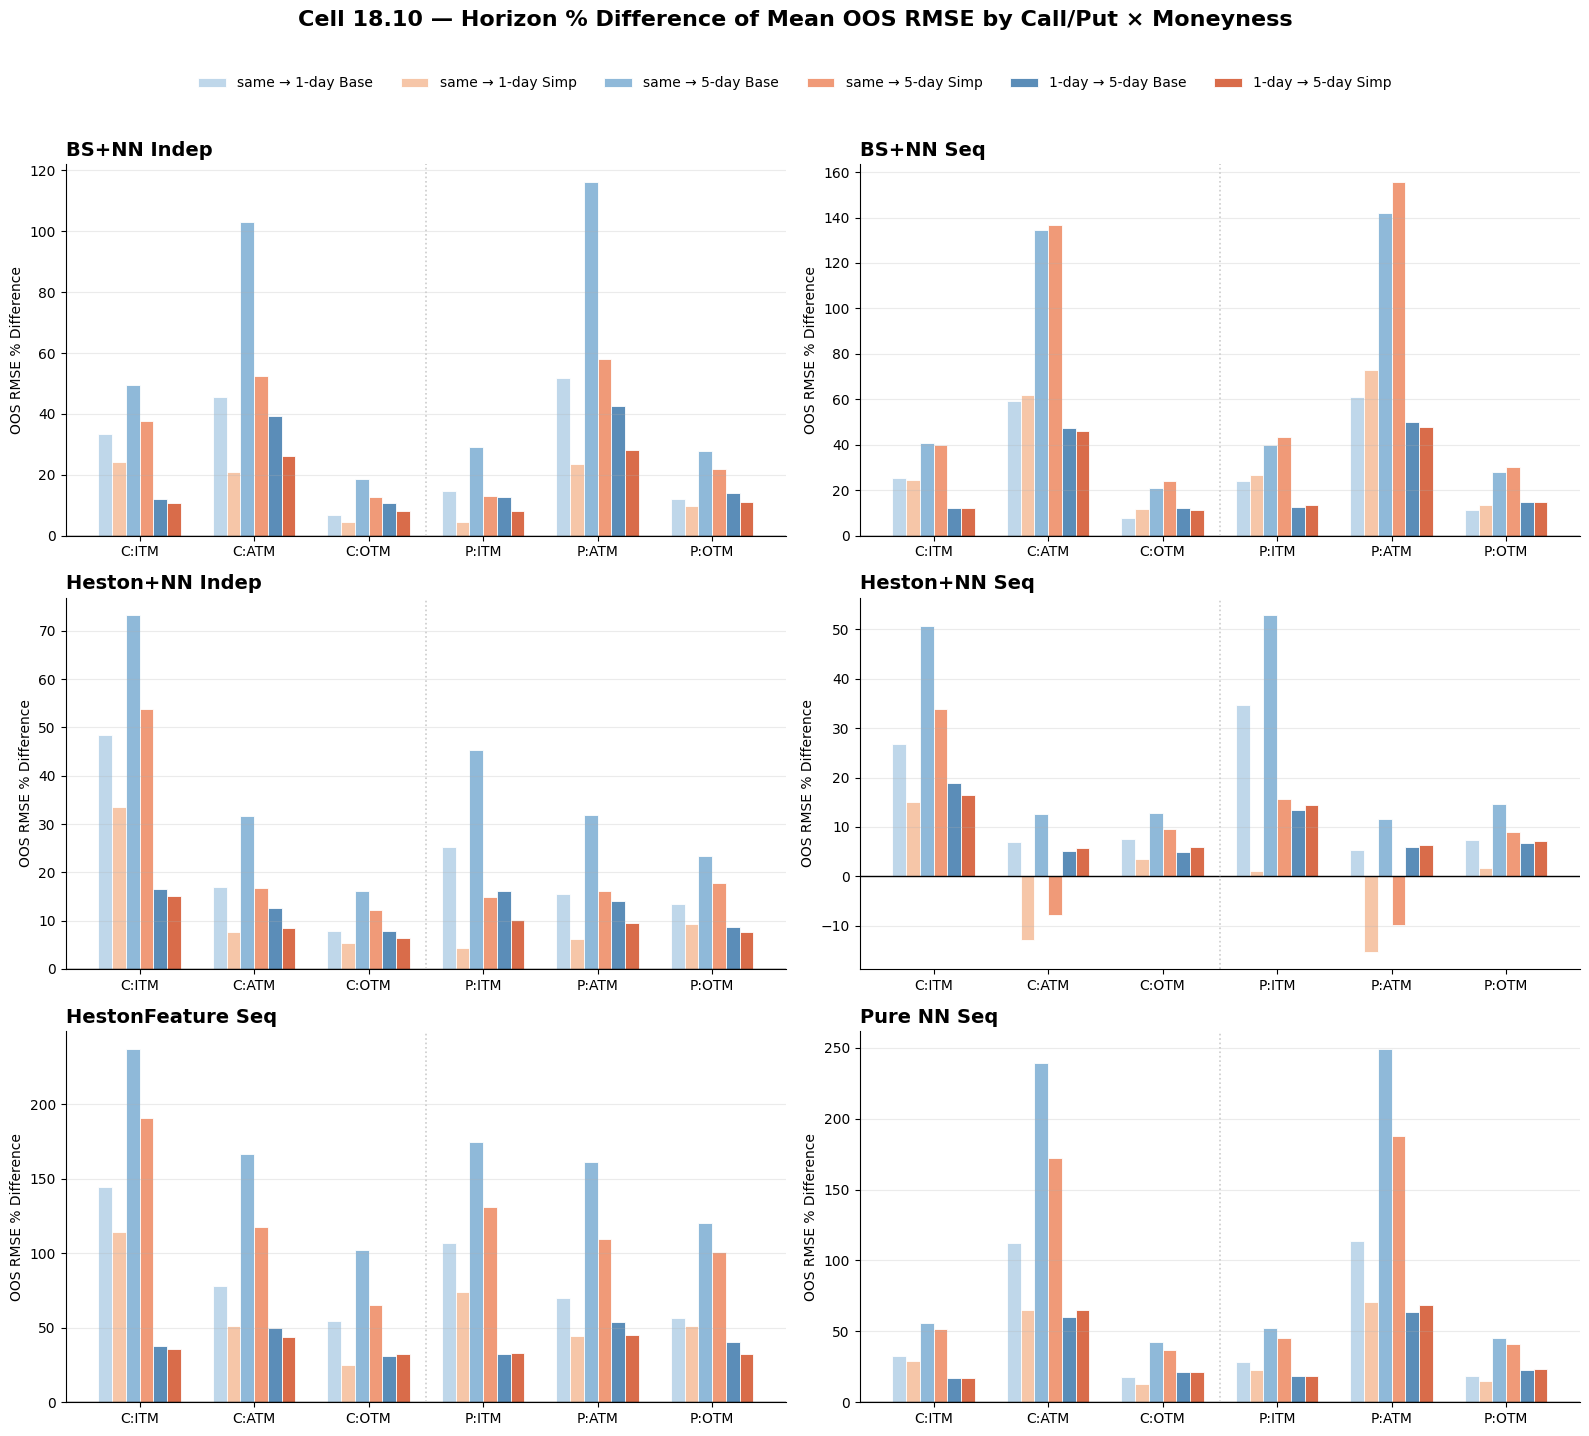

Saved: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/figures/cell1810_horizon_pctdiff_callput_bar.png


In [ ]:
# =============================================================================
# CELL 18.10 — Bar chart for Cell 18.8:
#   Horizon-pair % difference of mean OOS RMSE, by Call/Put × Moneyness.
#   Baseline vs Simpler.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import os

def _plot_cell1810(df):
    frameworks = df["Framework"].unique()
    cells = ["Call ITM", "Call ATM", "Call OTM", "Put ITM", "Put ATM", "Put OTM"]

    pair_labels = [_PAIR_LABEL[p] for p in _PAIRS]

    # Baseline = blue family, Simpler = orange family.
    # Within each family, colors get darker by horizon pair.
    _BASE_COLORS = ["#BFD7EA", "#8FB9D9", "#5B8DB8"]
    _SIMP_COLORS = ["#F6C6A8", "#F09A78", "#D96C4A"]

    series = []
    for i, pl in enumerate(pair_labels):
        series.append((f"{pl} Base", f"{pl}|base", _BASE_COLORS[i]))
        series.append((f"{pl} Simp", f"{pl}|simp", _SIMP_COLORS[i]))

    n_fw = len(frameworks)
    ncols = 2
    nrows = int(np.ceil(n_fw / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4.5 * nrows),
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    x = np.arange(len(cells))
    width = 0.12
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width

    for ax, fw in zip(axes, frameworks):
        sub = df[df["Framework"] == fw].set_index("Cell").reindex(cells)

        for i, (label, col, color) in enumerate(series):
            vals = sub[col].values.astype(float)
            ax.bar(
                x + offsets[i],
                vals,
                width,
                label=label,
                color=color,
                edgecolor="white",
                linewidth=0.6
            )

        ax.axhline(0, color="black", linewidth=1)
        ax.axvline(2.5, color="#cccccc", linestyle=":", linewidth=1.2)

        ax.set_title(fw, fontsize=14, fontweight="bold", loc="left")
        ax.set_xticks(x)
        ax.set_xticklabels(["C:ITM", "C:ATM", "C:OTM", "P:ITM", "P:ATM", "P:OTM"])
        ax.set_ylabel("OOS RMSE % Difference")
        ax.grid(axis="y", alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(frameworks):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        "Cell 18.10 — Horizon % Difference of Mean OOS RMSE by Call/Put × Moneyness",
        fontsize=16,
        fontweight="bold",
        y=1.06
    )

    fig.tight_layout()

    outpath = os.path.join(_W18_FIGDIR, "cell1810_horizon_pctdiff_callput_bar.png")
    os.makedirs(_W18_FIGDIR, exist_ok=True)
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)

_plot_cell1810(df_188)

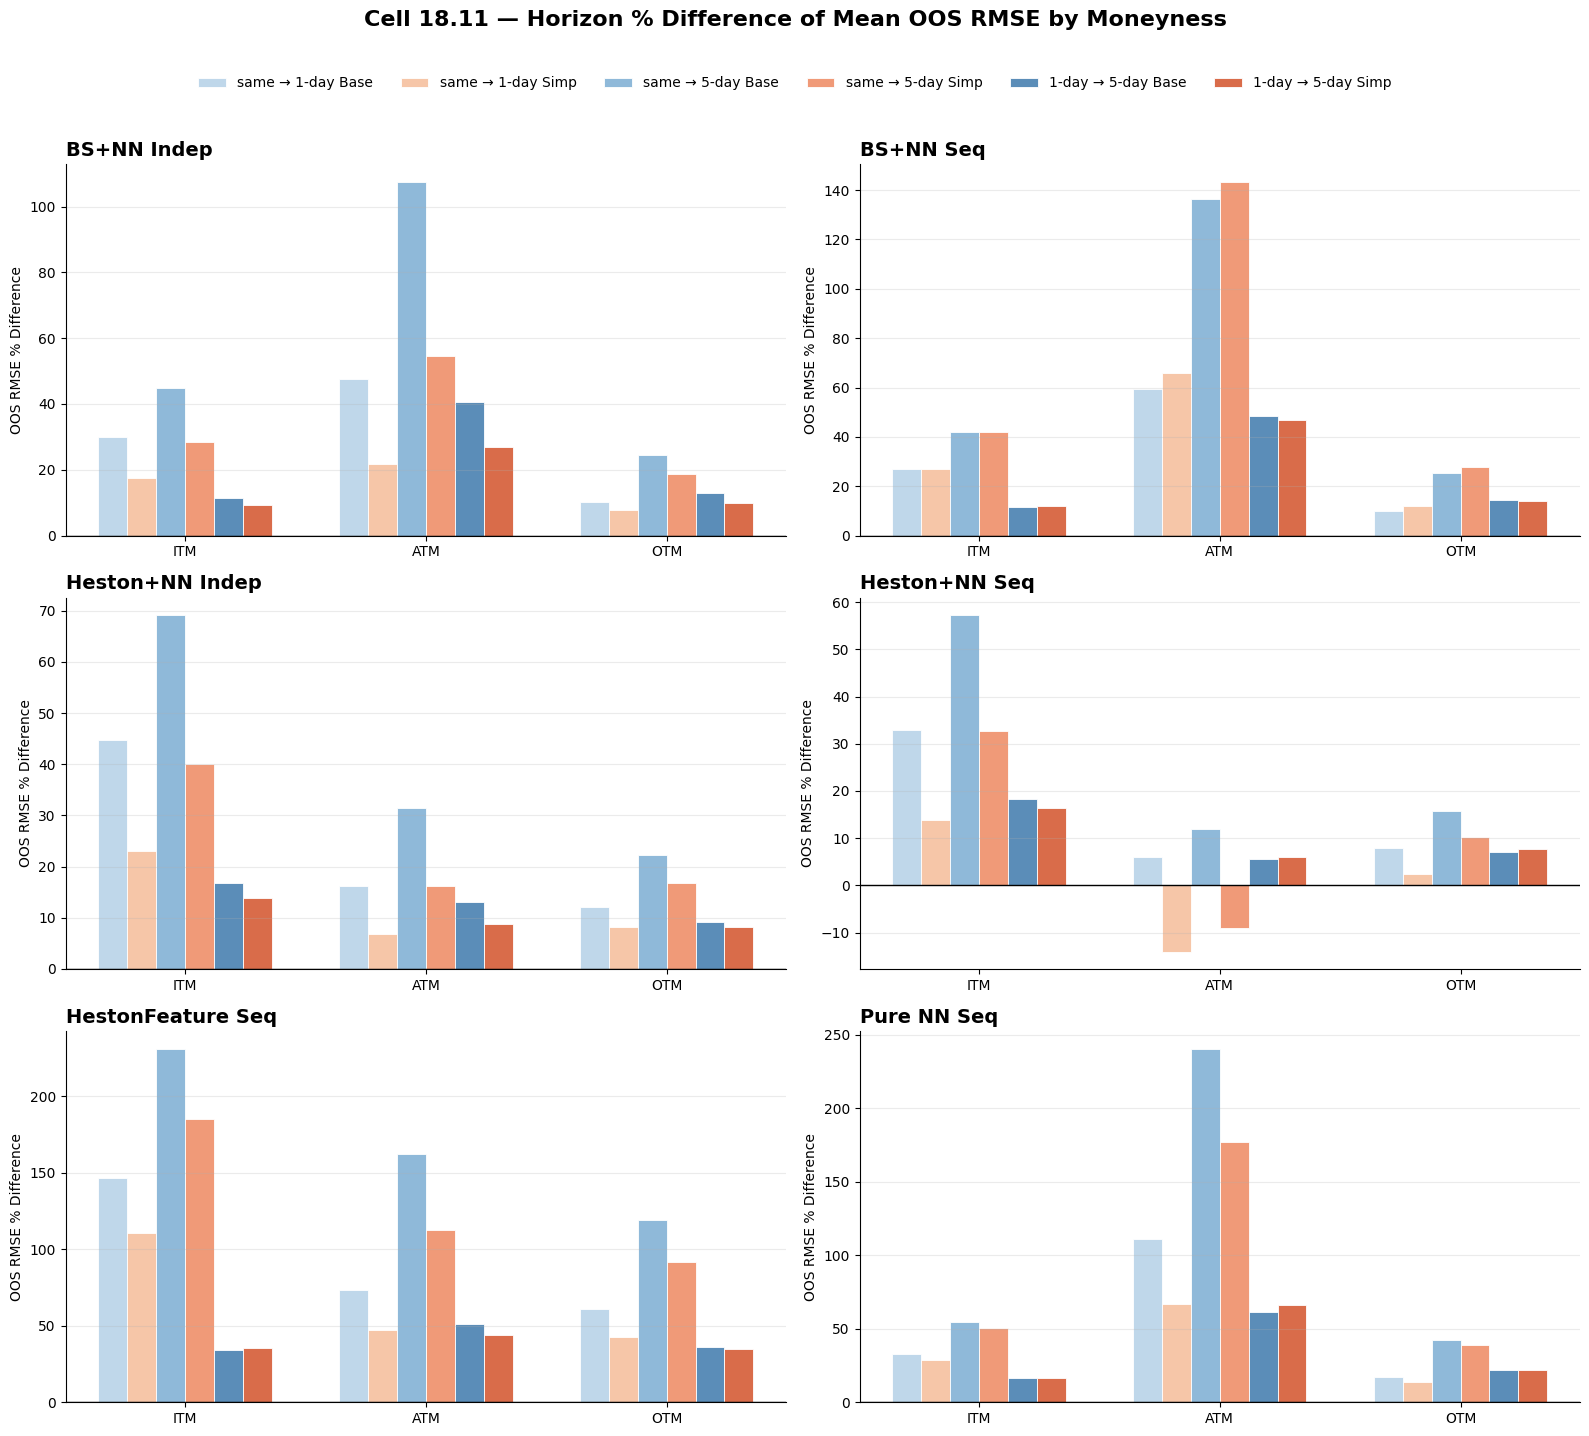

Saved: runs/week18_overfitting_study_dropout_vs_simpler/20260624-025614/figures/cell1811_horizon_pctdiff_moneyness_bar.png


In [ ]:
# =============================================================================
# CELL 18.11 — Bar chart for Cell 18.9:
#   Horizon-pair % difference of mean OOS RMSE, by Moneyness only.
#   Baseline vs Simpler.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import os

def _plot_cell1811(df):
    frameworks = df["Framework"].unique()
    buckets = ["ITM", "ATM", "OTM"]

    pair_labels = [_PAIR_LABEL[p] for p in _PAIRS]

    # Baseline = blue family, Simpler = orange family.
    # Within each family, colors get darker by horizon pair.
    _BASE_COLORS = ["#BFD7EA", "#8FB9D9", "#5B8DB8"]
    _SIMP_COLORS = ["#F6C6A8", "#F09A78", "#D96C4A"]

    series = []
    for i, pl in enumerate(pair_labels):
        series.append((f"{pl} Base", f"{pl}|base", _BASE_COLORS[i]))
        series.append((f"{pl} Simp", f"{pl}|simp", _SIMP_COLORS[i]))

    n_fw = len(frameworks)
    ncols = 2
    nrows = int(np.ceil(n_fw / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4.5 * nrows),
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    x = np.arange(len(buckets))
    width = 0.12
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width

    for ax, fw in zip(axes, frameworks):
        sub = df[df["Framework"] == fw].set_index("Bucket").reindex(buckets)

        for i, (label, col, color) in enumerate(series):
            vals = sub[col].values.astype(float)
            ax.bar(
                x + offsets[i],
                vals,
                width,
                label=label,
                color=color,
                edgecolor="white",
                linewidth=0.6
            )

        ax.axhline(0, color="black", linewidth=1)

        ax.set_title(fw, fontsize=14, fontweight="bold", loc="left")
        ax.set_xticks(x)
        ax.set_xticklabels(buckets)
        ax.set_ylabel("OOS RMSE % Difference")
        ax.grid(axis="y", alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(frameworks):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        "Cell 18.11 — Horizon % Difference of Mean OOS RMSE by Moneyness",
        fontsize=16,
        fontweight="bold",
        y=1.06
    )

    fig.tight_layout()

    outpath = os.path.join(_W18_FIGDIR, "cell1811_horizon_pctdiff_moneyness_bar.png")
    os.makedirs(_W18_FIGDIR, exist_ok=True)
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)

_plot_cell1811(df_189)

In [ ]:
# =============================================================================
# WEEK 18 SUMMARY
# =============================================================================

summary_w18 = """
WEEK 18 SUMMARY — Overfitting Study: Baseline vs Simpler Arch vs Dropout

================================================================
MOTIVATION (Professor Schafer)
================================================================
Diagnose whether the baseline NN frameworks overfit, and test two regularization
routes for closing the in-sample / out-of-sample gap. Professor's direction:
increase model complexity paired with dropout, and compare against a simplified
architecture, focusing on the overfit ratio = 100*(OOS-IS)/IS.

================================================================
THREE-TASK DESIGN
================================================================
Task 1 — Baseline:   800 epochs / batch 32, default architecture, no dropout.
Task 2 — Simpler:    800 epochs / batch 32, simplified (16,8) architecture.
Task 3 — Dropout:    dropout sweep p = 0.1 / 0.2 / 0.3.

CRITICAL: Tasks 1 and 2 share an identical JSON schema (no arch/reg fields) and
are distinguished ONLY by their root folder, so each tree is tagged with a task
at load time. A guard flags any two tasks loading byte-identical OOS series, which
would indicate a stale or duplicated folder.

================================================================
LOADING AND COVERAGE (Cells 18.0-18.1)
================================================================
- Fixed run path (not a fresh timestamped run) so a Colab disconnect only requires
  re-running the scaffold; folder location stays stable.
- Discovers results_*.json across all three task trees, tags each with task and
  dropout_p, computes IS/OOS RMSE, overfit gap (pp) and overfit ratio (%).
- Builds a coverage matrix, a side-by-side three-task comparison table at the focal
  horizon (5-day-ahead), and delta-vs-baseline columns (Δratio<0 = less overfit,
  ΔOOS<=0 = no out-of-sample cost).

================================================================
DROPOUT ANALYSIS (Cells 18.2-18.4)
================================================================
- Baseline (p=0) vs each dropout level: overfit-ratio table (headline) and
  absolute OOS RMSE table (guardrail), with clustered bars per framework.
- Dropout trend with baseline as the p=0 anchor (open marker), wanting the ratio
  to fall without OOS RMSE rising.
- 60-day MA IS vs OOS curves overlaying baseline against each dropout level.

================================================================
THREE-TASK AND BUCKET COMPARISONS (Cells 18.5-18.11)
================================================================
- Headline three-task bar chart: overfit ratio and absolute OOS by task, with the
  best dropout level per config selected.
- Table-6 call/put x moneyness loaded across all tasks; baseline/simpler 6-cell
  tables synthesized from results_ callput fields since those runs never wrote
  table6 JSONs.
- 60-day MA OOS RMSE by moneyness bucket, baseline bold-black against dropout.
- Table-6 OOS RMSE by Call/Put x moneyness, baseline vs all dropout levels.
- Horizon-pair percent-difference tables and bar charts (same->1day, same->5day,
  1day->5day), by Call/Put x moneyness and by moneyness only, baseline vs simpler.

================================================================
ARTIFACTS
================================================================
- w18_three_task_compare_{focal}.csv
- figures/w18_baseline_vs_dropout_summary_{focal}.png
- figures/w18_dropout_sweep_from_baseline_{focal}.png
- figures/w18_ma60_is_vs_oos_baseline_and_dropout_{focal}.png
- figures/w18_three_task_comparison_{focal}.png
- figures/w18_ma60_oos_by_moneyness_{focal}.png
- figures/w18_table6_callput_moneyness_all_dropout_{focal}.png
- figures/cell188_horizon_pctdiff_callput.csv, cell189_horizon_pctdiff_moneyness.csv
- figures/cell1810_*.png, cell1811_*.png

Next step:
Per Professor Schafer's direction, extend to increased model complexity paired
with dropout (p=0.4) as the next experimental step in the regularization study.
""".strip()

print(summary_w18)
